# Project 1 on Machine Learning: regression analysis, resampling methods and gradient descent

**Data Analysis and Machine Learning FYS-STK3155/FYS4155, University of Oslo, fall 2026**

**Deadline: October 5 (midnight), 2026.** Published August 31, 2026.

This notebook is the Jupyter version of the project text (`Project1.pdf`). The
code cells are *starting points*, not solutions: they set up the data and show
the automatic-differentiation check asked for in part e). Everything else is
yours to write.

## Preamble: note on writing reports, using reference material, AI and other tools

We want you to answer the three different projects by handing in reports
written like a standard scientific/technical report. The links at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/Projects>
contain more information. There you can find examples of previous reports, the
projects themselves, how we grade reports etc. How to write reports will also be
discussed during the various lab sessions. Please do ask us if you are in doubt.
In that folder you will find how we evaluate the projects. You will receive a
feedback with a final score for each project.

When using codes and material from other sources, you should refer to these in
the bibliography of your report, indicating wherefrom you for example got the
code, whether this is from the lecture notes, software like **Scikit-Learn**,
**JAX**, **TensorFlow**, **PyTorch** or other sources. These sources should
always be cited correctly. How to cite some of the libraries is often indicated
from their corresponding GitHub sites or websites; see for example how to cite
Scikit-Learn at <https://scikit-learn.org/dev/about.html>.

We encourage you to use Large Language models (LLMs) like
[ChatGPT](https://openai.com/chatgpt/), [Claude](https://claude.ai) or similar
in writing the report and in developing your code. In the report, you should
after the conclusions, write a declaration on how you have used LLMs following
the instructions at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/blob/main/LLM_Usage_Declaration_Guidelines.md>.
Failing to do so, <u>leads to an automatic deduction of five (5) points out of
the final score of 100 for the project</u>. Remember that *you* are responsible
for every line of code and every claim in the report: be prepared to explain and
defend all of it. If you use LLMs, please take a look at the guidelines at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/UsingLLMs>
on how to use these tools efficiently.

If you would like to study other data sets, feel free to propose other sets.
What we have proposed here are mere suggestions from our side. If you opt for
another data set, consider using a set which has been studied in the scientific
literature. This makes it easier for you to compare and analyze your results.
Comparing with existing results from the scientific literature is also an
essential element of the scientific discussion. The University of California at
Irvine with its Machine Learning repository at
<https://archive.ics.uci.edu/ml/index.php> is an excellent site to look up for
examples and inspiration. [Kaggle.com](https://www.kaggle.com/) is an equally
interesting site. Feel free to explore these sites and/or ask us for inputs
relevant to your discipline. When selecting other data sets, make sure these
are sets used for regression problems (not classification).

## Regression analysis, resampling methods and gradient descent

The main aim of this project is to study in more detail various regression
methods, including Ordinary Least Squares (OLS) regression, Ridge regression and
Lasso regression, together with the two resampling techniques (the bootstrap and
cross-validation) that let us assess and select models, and the gradient descent
methods that will be our optimizers for the rest of the course. In addition to
the scientific part, in this course we want also to give you an experience in
writing scientific reports.

We will study how to fit polynomials to a specific one-dimensional function
(feel free to replace the suggested function with more complicated ones). We
will use Runge's function (see
<https://en.wikipedia.org/wiki/Runge%27s_phenomenon> for a discussion),

$$
f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1].
$$

The project is organized so that it follows the weekly exercises and lectures of
the first weeks of the course:

- **Parts a) and b):** OLS and Ridge regression with closed-form solutions
  (weeks 34–36; the exercise sets of weeks 35 and 36 can be reused directly).
- **Parts c) and d):** the bias-variance tradeoff studied with the bootstrap,
  and cross-validation (week 36; Chapter 2, Sections 2.9–2.12 of the lecture
  notes).
- **Parts e) and f):** replacing the closed-form solutions by gradient descent,
  with gradients computed both analytically and by automatic differentiation,
  and with momentum and adaptive learning rates (weeks 37–38; Chapter 4).
- **Parts g) and h):** Lasso regression, our first method without a closed-form
  solution, and stochastic gradient descent (Chapter 4 of the lecture notes).
- **Part i):** the final comparison of OLS, Ridge and Lasso using
  cross-validation.

The analytical parts (in particular the derivation of the bias-variance
decomposition in part c) belong in the theory section of your report.
The material for solving the various exercises is covered by Chapters 2–4 of
the lecture notes and the lecture material for weeks 34–38.

In [1]:
from pathlib import Path

BASE_DIR = Path.cwd()
PLOT_DIR = BASE_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

### Setting up the data

A starting point: Runge's function on $[-1,1]$ with additive Gaussian noise,
and a polynomial design matrix. Feel free to change everything.

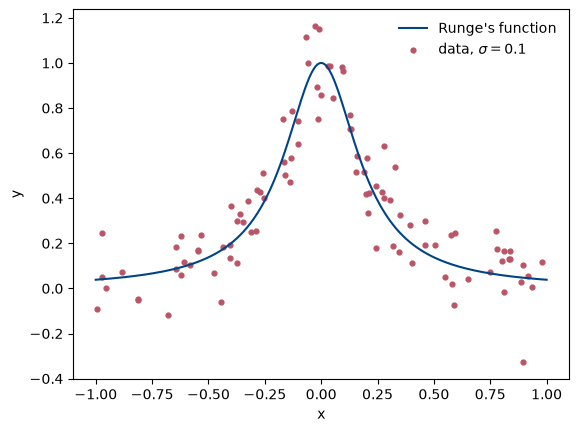

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
#plt.savefig(PLOT_DIR / "runges_function.png", dpi=300, bbox_inches="tight")
plt.show()

### Part a): Ordinary Least Squares (OLS) for the Runge function

We will generate our own data set for the above function $f(x)$ with
$x\in[-1,1]$, using either a uniform distribution or a fixed step size to set up
the array of $x$ values. You should also explore the addition of normally
distributed noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$ to the function; a
noise level of $\sigma\approx0.1$ is a good starting point, but study how your
conclusions depend on it.

**Write your own code** (using for example the pseudoinverse function `pinv`
from `numpy`, or the SVD directly) and perform a standard **ordinary least
squares regression** analysis using polynomials in $x$ up to order 15 or higher.
Explore the dependence on the number of data points and the polynomial degree.

Evaluate the mean squared error (MSE)

$$
\mathrm{MSE}(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
$i$-th sample and $y_i$ is the corresponding true value, then the score $R^2$ is
defined as

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
\qquad
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1}y_i .
$$

Plot the resulting scores (MSE and $R^2$) as functions of the polynomial degree
(here up to polynomial degree 15). Plot also the parameters $\boldsymbol{\theta}$
as you increase the order of the polynomial. Comment your results.

Your code has to include a scaling/centering of the data (for example by
subtracting the mean value), and a split of the data in training and test data.
For the splitting you can either write your own code or use for example the
function `train_test_split` provided by **Scikit-Learn** (make sure you have
installed it). **You should present a critical discussion of why and how you
have scaled/ or not scaled the data** (see Section 3.13 of the lecture notes,
the Tuesday session of week 35 and the pertinent notebook for week 35).

It is normal in essentially all Machine Learning studies to split the data in a
training set and a test set (eventually also an additional validation set).
There is no explicit recipe for how much data should be included as training
data and say test data. An accepted rule of thumb is to use approximately $2/3$
to $4/5$ of the data as training data.

You can easily reuse the solutions to your exercises from week 35 (the
analytical derivatives of the cost function, your own OLS code, and the
train/test analysis). See also the lecture slides from weeks 34 and 35 and
Chapter 3 of the lecture notes. On scaling, we recommend reading the following
section from the Scikit-Learn documentation:
<https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html>.
See also Section 3.13 of the lecture notes.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

def model_creator_OLD(x_train, x_test, y_train, y_test, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)    #Generate polynomial and interaction features
    X_train_poly = poly.fit_transform(x_train.reshape(-1, 1))       #Fits transformer to X and y and returns a transformed version of X
    X_test_poly = poly.transform(x_test.reshape(-1, 1))             #Transform data to polynomial features

    scaler = StandardScaler()                                       #Standardize features by removing the mean and scaling to unit variance 

    X_tr_scaled = X_train_poly#scaler.fit_transform(X_train_poly)                #Standardize training data
    X_te_scaled = X_test_poly#scaler.transform(X_test_poly)                     #transform test data to fit the same form as training data

    # Fit OLS model
    poly_reg_model = LinearRegression(fit_intercept=True)           #Create OLS linear regression 
    poly_reg_model.fit(X_tr_scaled, y_train.ravel())                #Apply model to dataset

    # Predictions
    ypredict_train = poly_reg_model.predict(X_tr_scaled)            #Predict training model using the linear model
    ypredict_test = poly_reg_model.predict(X_te_scaled)             #Predict test model using the linear model
    return ypredict_train, ypredict_test, poly_reg_model.coef_

def model_creator(x_train, x_test, y_train, y_test, degree,
                  method="OLS", lmbda=0.0):
    
    poly = PolynomialFeatures(degree=degree, include_bias=False)    # Create polynomial features up to the selected degree.
    
    X_train_poly = poly.fit_transform(x_train.reshape(-1, 1))       # Fit the polynomial transformation on the training inputs.

    X_test_poly = poly.transform(x_test.reshape(-1, 1))             # Apply the same polynomial transformation to the test inputs.

    scaler = StandardScaler()                                       # Create a scaler for the polynomial features.

    X_tr_scaled = scaler.fit_transform(X_train_poly)                # Fit the scaler only on training data to avoid test-data leakage.

    X_te_scaled = scaler.transform(X_test_poly)                     # Use the training-data scaling parameters on the test data.

    # Select the regression method requested by the caller.
    if method == "OLS":
        model = LinearRegression(fit_intercept=True)
    elif method == "Ridge":
        model = Ridge(alpha=lmbda, fit_intercept=True)              # For Ridge, lmbda is passed to Scikit-Learn as alpha.
    else:
        raise ValueError("method must be either 'OLS' or 'Ridge'")  # Stop if wrong method input

    
    model.fit(X_tr_scaled, y_train.ravel())                         # Fit the selected model to the scaled training data.

    # Predict the responses for the training and test sets.
    ypredict_train = model.predict(X_tr_scaled)
    ypredict_test = model.predict(X_te_scaled)

    # Return the predictions and fitted coefficients for either method.
    return ypredict_train, ypredict_test, model.coef_


degrees = range(1, 16)      # Degrees from 0 to 15

# storage arrays
mse_train = []
mse_test = []
R2_train = []
R2_test = []
theta = []

x_train, x_test, y_train, y_test = train_test_split(        # split data into test (20% of data) and training sets (80% of data)
    x, y, test_size=0.2, random_state=2026)



for degree in degrees:
    ypredict_train, ypredict_test, coefficients= model_creator(             # call function to create model and get its results
                                x_train, x_test, y_train, y_test, degree)  

    # Calculate MSE
    mse_train.append(mean_squared_error(y_train.ravel(), ypredict_train))
    mse_test.append(mean_squared_error(y_test.ravel(), ypredict_test))
    # Calculate R2
    R2_train.append(r2_score(y_train.ravel(), ypredict_train))
    R2_test.append(r2_score(y_test.ravel(), ypredict_test))

    theta.append(coefficients)

Optimal degree: 8
Minimum test MSE: 0.018712
R^2 for optimal degree:0.8489275418099275
Training R^2 for degree 1:0.0019257604927785943, Test R^2 for degree 1:-0.1352869767244469


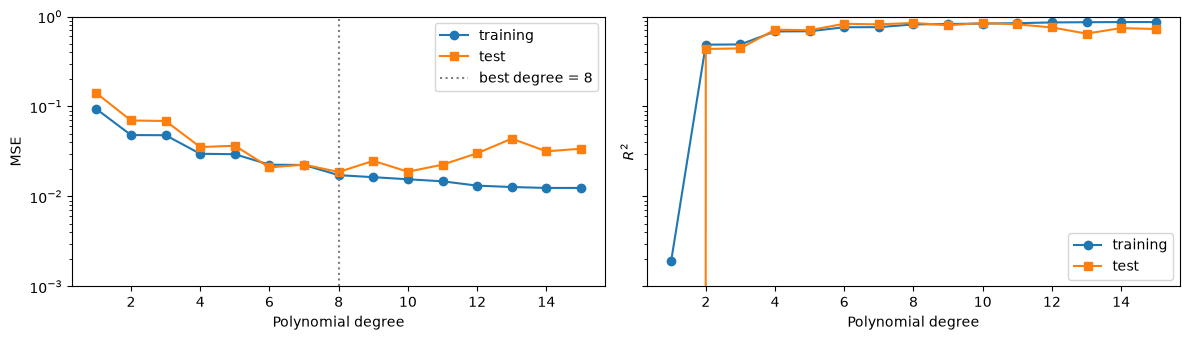

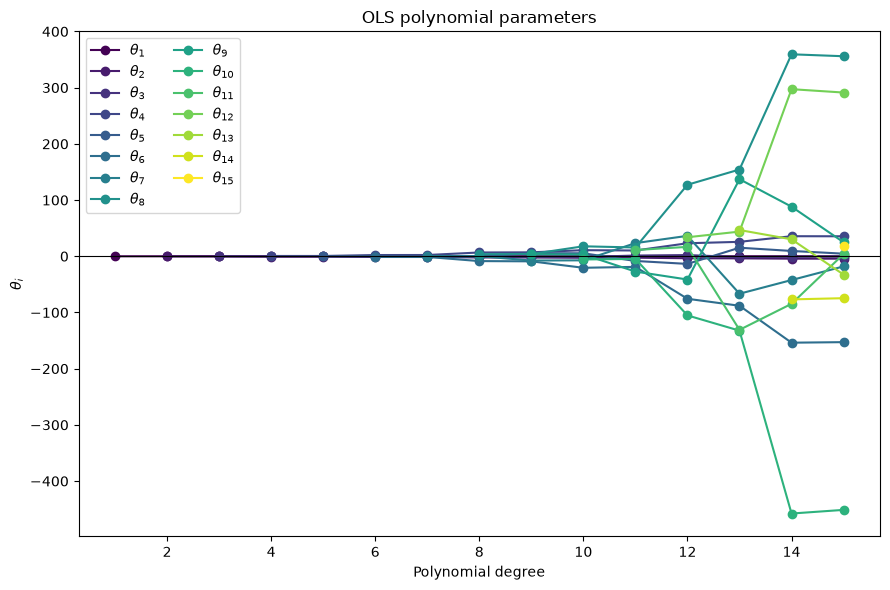

In [5]:
# plotting MSE and R^2 
best = int(np.argmin(mse_test))
best_index = np.argmin(mse_test)
best_d = list(degrees)[best_index]

print(f"Optimal degree: {best_d}")
print(f"Minimum test MSE: {mse_test[best_index]:.6f}")
print(f"R^2 for optimal degree:{R2_test[best_index]}")
print(f"Training R^2 for degree 1:{R2_train[0]}, Test R^2 for degree 1:{R2_test[0]}")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

axes[0].plot(degrees, mse_train, "o-", label="training")
axes[0].plot(degrees, mse_test, "s-", label="test")
axes[0].axvline(
    best_d, color="gray", ls=":",
    label=f"best degree = {best_d}"
)
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].set_ylim(1e-3, 1e0)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(degrees, R2_train, "o-", label="training")
axes[1].plot(degrees, R2_test, "s-", label="test")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("$R^2$")
axes[1].set_yscale("log")
axes[1].legend()
#plt.savefig(PLOT_DIR / "OLS_MSE_and_R2.png", dpi=300, bbox_inches="tight")
fig.tight_layout()
plt.show()

# Plot the parameters theta

number_of_coefficients = max(len(coefficients) for coefficients in theta)

fig, ax = plt.subplots(figsize=(9, 6))

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, number_of_coefficients))

for coefficient_index in range(number_of_coefficients):
    available_points = [
        (degree, coefficients[coefficient_index])
        for degree, coefficients in zip(degrees, theta)
        if coefficient_index < len(coefficients)
    ]

    available_degrees, coefficient_values = zip(*available_points)

    ax.plot(
        available_degrees,
        coefficient_values,
        "o-",
        color=colors[coefficient_index],
        label=fr"$\theta_{{{coefficient_index + 1}}}$"
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Polynomial degree")
ax.set_ylabel(r"$\theta_i$")
ax.set_title("OLS polynomial parameters")
ax.legend(ncol=2)
#plt.savefig(PLOT_DIR / "OLS_polynomial_params.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

Comment your results:
The best performance for the OLS regression for the Runge function is given by a degree $8$ polynomial, with a test MSE of $0.0187$. The corresponding test $\mathrm{R}^2$ score for the optimal degree is $0.849$, meaning that the model explain approximately $85 \%$ of the variation of the test target values. Note that the training $\mathrm{R}^2$ score for a degree $1$ polynomial is substantially smaller (model explains $\approx 0.2 \% of variation$) than for polynomials of other tested degrees. The test $\mathrm{R}^2$ score for degree $1$ polynomial is negative, indicating that the model performs worse on the test data than the baseline predictor that always predicts the mean of the test target values.

The parameter plot shows how each parameter $\theta_i$ changes as the polynomial degree is increased, with $\theta_i$ first appearing when the polynomial degree reaches $i$. For low degrees, the parameters are relatively small and stable. However, as the degree increases, especially around degrees $10$-$15$ some coefficients become large in magnitude. These large parameter values are associated with the polynomial features becoming strongly correlated, causing the design matrix to become ill-conditioned. This makes the fitted model increasingly sensitive to small changes in the data, and may lead to unstable polynomial fits at high degrees.

In the function `model_creator` the input data are scaled by using the Scikit-Learn's standard scaler `StandardScaler`, which use $x_{scaled} = (x - \bar x) / \sigma$, where $\bar x$ is the mean of the training data and $\sigma$ its standatd deviation. The scaler is fitted only to the training data and subsequently applied to the test data, thereby avoiding information from the test set being used during training. The scaling does, however, change the numerical values of the coefficients $\theta_i$ although it does not change the fitted function or its predictions for OLS when the transformation is applied consistently. As a consequence, the scaling could be removed to increase the efficiency of the function when using the OLS.

The scaling is nevertheless retained because the same function is used for other methods where scaling matters, such as Ridge and Lasso methods. Additionally, using the same preprocessing for different regression methods makes their performance easier to compare.



### Part b): Adding Ridge regression for the Runge function

Write your own code for the Ridge method, as done in the previous part. The
lecture notes from weeks 35 and 36 contain more information, as well as your
exercises from weeks 35 and 36. Feel free to reuse this material.

Perform the same analysis as you did in the previous part but now for different
values of the penalty parameter $\lambda$. Compare and analyze your results with
those obtained in part a) with the OLS method. Study the dependence on
$\lambda$, and connect what you see to the shrinkage of the singular-value modes
discussed in the lectures (Section 3.8 of the lecture notes).

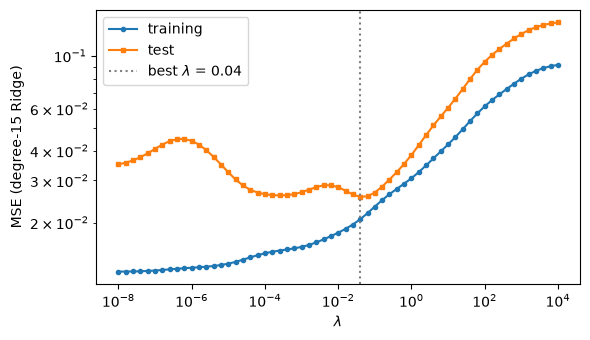

Best Ridge test MSE: 0.02562 at lambda = 0.0398


In [6]:
# Your code for part b) here




degree_ridge = 15                           # Keep the polynomial degree fixed while testing different Ridge penalties.


lambdas = np.logspace(-8, 4, 61)            # Search over several lambda values on a logarithmic scale.

# Create lists for the training and test MSE values.
mse_ridge_train = []
mse_ridge_test = []

# Fit one Ridge model for each lambda value.
for lmbda in lambdas:
    ypred_train, ypred_test, coefficients = model_creator(  x_train, x_test,    # Use the same function for every Ridge model in the sweep.
                                                            y_train, y_test,
                                                            degree=degree_ridge,
                                                            method="Ridge",
                                                            lmbda=lmbda )

    
    mse_ridge_train.append(mean_squared_error(y_train, ypred_train))    # Measure the training error for the current lambda.

    
    mse_ridge_test.append(mean_squared_error(y_test, ypred_test))       # Measure the test error for the current lambda.


best_ridge_index = int(np.argmin(mse_ridge_test))                       # Find the lambda value with the smallest test MSE.

# Plot the training and test MSE as functions of lambda.
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_ridge_train, "o-", ms=3, label="training")
plt.plot(lambdas, mse_ridge_test, "s-", ms=3, label="test")


plt.axvline(                            # Mark the lambda value that gives the lowest test error.
    lambdas[best_ridge_index],
    color="gray",
    ls=":",
    label=rf"best $\lambda$ = {lambdas[best_ridge_index]:.2g}"
)

# Use logarithmic axes because lambda and MSE span different scales.
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel(f"MSE (degree-{degree_ridge} Ridge)")
plt.legend()
plt.tight_layout()
#plt.savefig(PLOT_DIR / "Ridge_regression.png", dpi=300, bbox_inches="tight")
plt.show()


print(                                  # Report the best Ridge result.
    f"Best Ridge test MSE: {mse_ridge_test[best_ridge_index]:.5f} "
    f"at lambda = {lambdas[best_ridge_index]:.3g}"
)

### Part c): The bias-variance tradeoff and the bootstrap

Our aim here is to study the bias-variance tradeoff by implementing the
**bootstrap** resampling technique. **We will only use the simpler ordinary
least squares here.**

Before you perform an analysis of the bias-variance tradeoff on your test data,

- $\otimes$ make first a figure similar to Fig. 2.11 of Hastie, Tibshirani and Friedman.
Figure 2.11 of this reference displays only the test and training MSEs. The
test MSE can be used to indicate possible regions of low/high bias and variance.

You will most likely not get an equally smooth curve! 
- $\otimes$ You will also need to
increase the polynomial order and play around with the number of data points as
well (see the exercise sets from week 35 and week 36).

![Figure 2.11 of Hastie, Tibshirani and Friedman](/Users/paula/machine_learning_uio/img/fig_211.png)

##### prepare new data (more datapoints)

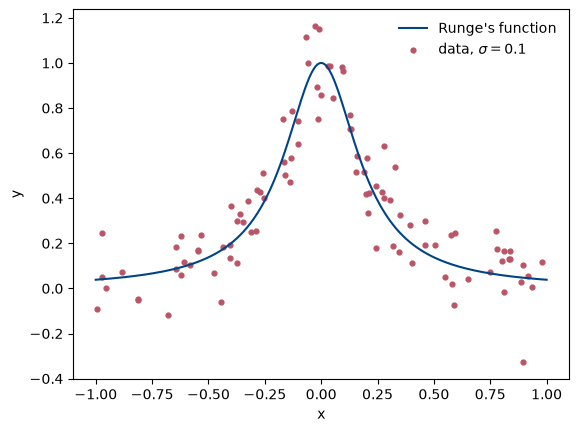

In [7]:
# first generate new data with more datapoints
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# plot
xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

##### repeat MSE-vs-degree analysis (w/o bootstrap)

In [8]:
# repeat OLS analysis
degrees = range(1, 20) # Degrees from 0 to 15

# storage arrays
mse_train = []
mse_test = []
R2_train = []
R2_test = []
theta = []

x_rs = x.reshape(-1,1)
y_rs = y.reshape(-1,1)

x_train, x_test, y_train, y_test = train_test_split(        # split data into test (20% of data) and training sets (80% of data)
    x_rs, y_rs, test_size=0.2, random_state=2026)

for degree in degrees:
    ypredict_train, ypredict_test, coefficients= model_creator(             # call function to create model and get its results
                                x_train, x_test, y_train, y_test, degree)  

    # Calculate MSE
    mse_train.append(mean_squared_error(y_train.ravel(), ypredict_train))
    mse_test.append(mean_squared_error(y_test.ravel(), ypredict_test))

    # Calculate R2
    R2_train.append(r2_score(y_train.ravel(), ypredict_train))
    R2_test.append(r2_score(y_test.ravel(), ypredict_test))

    theta.append(coefficients)

# plotting MSE and R^2 
best = int(np.argmin(mse_test))
best_index = np.argmin(mse_test)
best_d = list(degrees)[best_index]

print(f"Optimal degree: {best_d}")
print(f"Minimum test MSE: {mse_test[best_index]:.6f}")
print(f"R^2 for optimal degree:{R2_test[best_index]}")
print(f"Training R^2 for degree 1:{R2_train[0]}, Test R^2 for degree 1:{R2_test[0]}")

Optimal degree: 8
Minimum test MSE: 0.018712
R^2 for optimal degree:0.8489275418099275
Training R^2 for degree 1:0.0019257604927785943, Test R^2 for degree 1:-0.1352869767244469


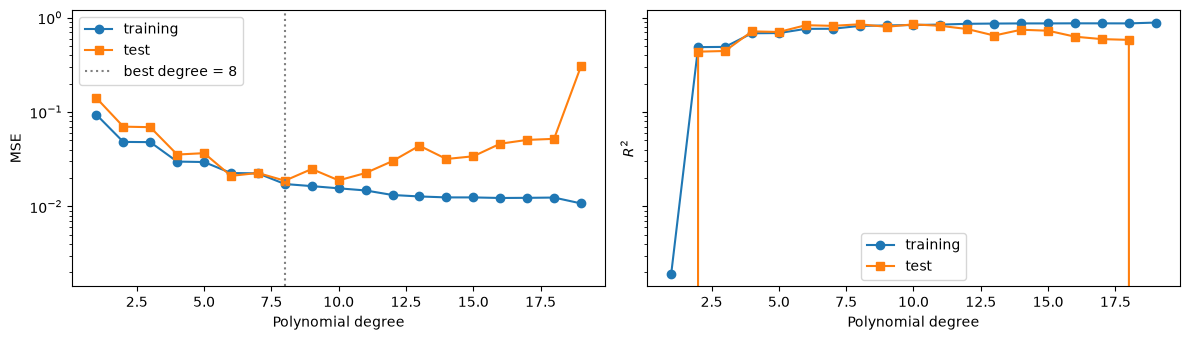

In [9]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

axes[0].plot(degrees, mse_train, "o-", label="training")
axes[0].plot(degrees, mse_test, "s-", label="test")
axes[0].axvline(
    best_d, color="gray", ls=":",
    label=f"best degree = {best_d}"
)
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
# axes[0].set_ylim(1e-3, 1e0)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(degrees, R2_train, "o-", label="training")
axes[1].plot(degrees, R2_test, "s-", label="test")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("$R^2$")
axes[1].set_yscale("log")
axes[1].legend()

fig.tight_layout()
plt.show()



##### analytical derivation of bias-variance-tradeoff (TODO)

With this result we move on to the bias-variance tradeoff analysis. Consider a
data set $\mathcal{L}$ consisting of the data
$\boldsymbol{X}_\mathcal{L}=\{(y_j,\boldsymbol{x}_j),\,j=0,\dots,n-1\}$, and
assume that the true data are generated from a noisy model

$$
\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon},
$$

where $\boldsymbol{\varepsilon}$ is normally distributed with mean zero and
variance $\sigma^2$. In our derivation of the ordinary least squares method we
defined an approximation to the function $f$ in terms of the parameters
$\boldsymbol{\theta}$ and the design matrix $\boldsymbol{X}$ which embody our
model, that is $\tilde{\boldsymbol{y}}=\boldsymbol{X}\boldsymbol{\theta}$. The
parameters $\boldsymbol{\theta}$ are in turn found by optimizing the mean squared
error via the cost function

$$
C(\boldsymbol{X},\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2
 = \mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right].
$$

Here the expected value $\mathbb{E}$ is the sample value.

Show that you can rewrite this in terms of a term which contains the variance of
the model itself (the so-called variance term), a term which measures the
deviation from the true data and the mean value of the model (the bias term) and
finally the variance of the noise. That is, show that

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
 = \mathrm{Bias}^2[\tilde{y}] + \mathrm{var}[\tilde{y}] + \sigma^2,
$$

with

$$
\mathrm{Bias}^2[\tilde{y}] = \mathbb{E}\left[\left(\boldsymbol{f}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right],
\qquad
\mathrm{var}[\tilde{y}] = \mathbb{E}\left[\left(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right]
 = \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2 .
$$



$\rightarrow$ From exercisesweek36.ipynb:

**2a)**
\begin{align*}
\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] &= \mathbb{E}[(f+\epsilon-\tilde{\boldsymbol{y}}+\mathbb{E}[\tilde{\boldsymbol{y}}]-\mathbb{E}
[\tilde{y}])^2] \\
&= \mathbb{E}[((f - \mathbb{E}[\tilde{\boldsymbol{y}}])-(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]) + \epsilon)^2]\\
&= \mathbb{E}[(f - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + (\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \epsilon^2 + 2\epsilon(f - \mathbb{E}[\tilde{\boldsymbol{y}}]) - 2\epsilon(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]) - (f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}])],
\end{align*}
the squared terms survive, the first and second crossterm disappears because $\mathbb{E}[\epsilon] = 0$, the final disappears because $\mathbb{E}[\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]] =\mathbb{E}[\tilde{\boldsymbol{y}}] - \mathbb{E}[\mathbb{E}[\tilde{\boldsymbol{y}}]] = \mathbb{E}[\tilde{\boldsymbol{y}}]-\mathbb{E}[\tilde{\boldsymbol{y}}] = 0$. From the course book the following is known to be true
\begin{equation*}
\mathbb{E}[(y-\tilde{y})^2] = \frac{1}{2} \sum_{i=0}^{n-1}(y_i - \tilde{y}_i).
\end{equation*}
Thus, the remaining expression is
\begin{equation*}
\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] = \frac{1}{n}\sum_i (f_i - \mathbb{E}[\tilde{y}])^2 + \frac{1}{n}\sum_i(\tilde{y}-\mathbb{E}[\tilde{y}]) + \sigma^2 \qquad \Box
\end{equation*}

**2b)**
The expectation value runs over the error of each prediction. 

From left to right: the first term is the $\mathrm{bias}^2$, the second the variance, and the final, is the irreducible error.

**2c)**
Let $\mathbb{E}[(\boldsymbol{y}_{test}-\tilde{\boldsymbol{y}})^2]$. The $\boldsymbol{y}_{test}$ is based on the test data of an underlying model. Therefore it will be a construct of the actual model plus an test error, i.e., $\boldsymbol{y}_{test} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$. By setting $f=y_{test}$ in the final expression of **a)**, the bias term will contain $\sigma^2$.

##### bootstrap implementation (OLS)


**Important note:** since the function $f(x)$ is unknown, in order to be able to
evaluate the bias we replace $f(\boldsymbol{x})$ in the expression for the bias
with $\boldsymbol{y}$; 
- discuss what this does to the measured bias term (it
absorbs the noise variance $\sigma^2$). Explain what the three terms mean and
discuss their interpretations, and state clearly over which randomness the
expectation values are taken.

- The answer to this exercise should be included in the theory part of the
report. This derivation is also part of the weekly exercises of week 36, and it
is Eq. (2.52) of Chapter 2 of the lecture notes.

- Perform then a bias-variance analysis of the Runge function by studying the MSE
value as function of the complexity of your model, using the **bootstrap**
resampling method to estimate the expectation values over training sets.

- Discuss the bias and variance tradeoff as function of your model complexity (the
degree of the polynomial) and the number of data points. You can follow the
code examples in Sections 2.10 and 2.11 of the lecture notes and the Tuesday
notebook of week 36 (`week36tuesday.ipynb`).

In [10]:
# Your code for part c) here
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample

# bootstrap parameters
bs_resamples = 100
maxdegree = 15
degrees = range(1, maxdegree+1) # overwrite degrees-array from 1 to maxdegree

# initialize error, bias and variance arrays
error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)

# loop over the degrees
for idx, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], bs_resamples))

    # loop over bootstrap samples
    for i in range(bs_resamples):
        x_boot, y_boot = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_boot, y_boot).predict(x_test).ravel()

    error[idx] = np.mean(np.mean((y_test - y_pred) ** 2, axis=1, keepdims=True))
    bias[idx] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True)) ** 2)
    variance[idx] = np.mean(np.var(y_pred, axis=1, keepdims=True))

# pick out best degree and print
best_degree = np.argmin(error)
print(
    f"Best degree: {best_degree}; "
    f"bootstrap test error: {error[best_degree]:.4f}"
)

Best degree: 7; bootstrap test error: 0.0381


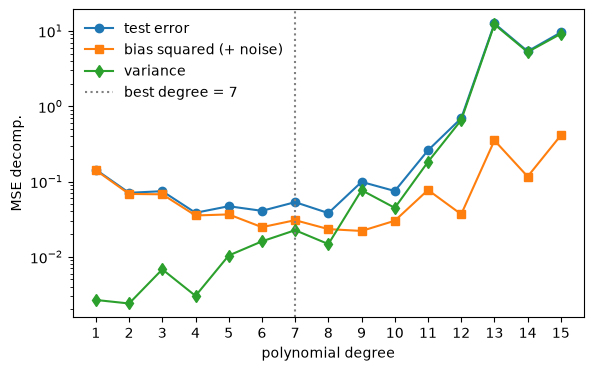

degree  0: error 0.1439  bias^2 0.1413  var 0.0027  sum 0.1439
degree  4: error 0.0470  bias^2 0.0366  var 0.0104  sum 0.0470
degree  6: error 0.0532  bias^2 0.0306  var 0.0226  sum 0.0532
degree 14: error 9.5722  bias^2 0.4107  var 9.1615  sum 9.5722


In [11]:
#plot
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(degrees, error, "o-", label="test error")
ax.plot(degrees, bias, "s-", label="bias squared (+ noise)")
ax.plot(degrees, variance, "d-", label="variance")
ax.axvline(
    best_degree,
    color="gray",
    linestyle=":",
    label=f"best degree = {best_degree}",
)
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomp.")
ax.set_xticks(degrees)
ax.legend(frameon=False)
#plt.savefig(PLOT_DIR / "OLS_bias_variance_decomp.png", dpi=300, bbox_inches="tight")
plt.show()


for degree in (0, 4, 6, maxdegree - 1):
    print(
        f"degree {degree:2d}: "
        f"error {error[degree]:.4f}  "
        f"bias^2 {bias[degree]:.4f}  "
        f"var {variance[degree]:.4f}  "
        f"sum {bias[degree] + variance[degree]:.4f}"
    )

It is odd that the bias goes up for larger degrees. This is an indication of ill-conditioning. -> Check the condition number k = lambda_max/ lambda_min or something of that sort.

- Make a scaled version of this and compare

### Part d): Cross-validation as a resampling technique

The aim here is to use another widely popular resampling technique, the
so-called cross-validation method (Section 2.12 of the lecture notes and the
Tuesday session of week 36). For Ridge and Lasso, see also Section 3.14 of the
lecture notes.

- Use the $k$-fold cross-validation functionality of **Scikit-Learn** (`KFold`
together with `cross_val_score`, or `cross_validate`) and evaluate again the
MSE function resulting from the test folds, for the OLS analysis of parts a)
and c) as a function of the polynomial degree, and for Ridge regression as a
function of both the polynomial degree and $\lambda$. 
- Try $k=5$ and $k=10$.
- Optionally, you can also write your own $k$-fold cross-validation code and
check that it reproduces the Scikit-Learn results when the two use the same
fold assignment (the Tuesday session of week 36 shows how).

--> just do the scikit learn 

- Compare the MSE you get from cross-validation with the one you got
from your **bootstrap** code in part c). Do the two methods point to the same
model complexity? Comment and interpret your results. 
- Make sure that any scaling or other preprocessing that learns from the data is performed *inside* the
cross-validation loop (fitted on the training folds only), and explain why this
matters.

##### OLS

- do k = 10

In [12]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# define number of folds for KFold cross-validation
k = [5, 10]

# initialize array to store info for plotting
mse_sklearn = np.zeros((maxdegree, len(k)))

# loop over number of folds (k)
for k_idx in range(len(k)):
    kfold = KFold(n_splits=k[k_idx], shuffle=True, random_state=2026)
    
    # loop over polynomial degrees
    for degree in range(maxdegree):
        #OLS
        poly = PolynomialFeatures(degree=degree+1, include_bias=False)  # Create polynomial features up to the selected degree.

        # scikit-learn: iterate over the folds
        pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(),
                                LinearRegression())
        scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error")
        mse_sklearn[degree, k_idx] = np.mean(-scores)



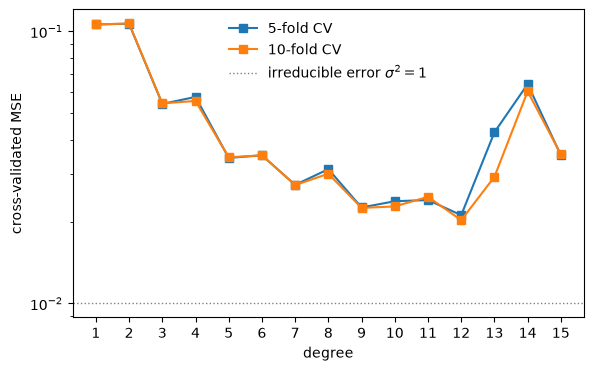

In [13]:
# plot & print
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for k_idx in range(len(k)):   
    ax.plot(degrees, mse_sklearn[:, k_idx], "s-", label=f"{k[k_idx]}-fold CV")
ax.axhline(sigma**2, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
ax.set_yscale("log")
ax.set_xlabel("degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
ax.set_xticks(degrees)
#plt.savefig(PLOT_DIR / "OLS_cross_validation.png", dpi=300, bbox_inches="tight")
plt.show()

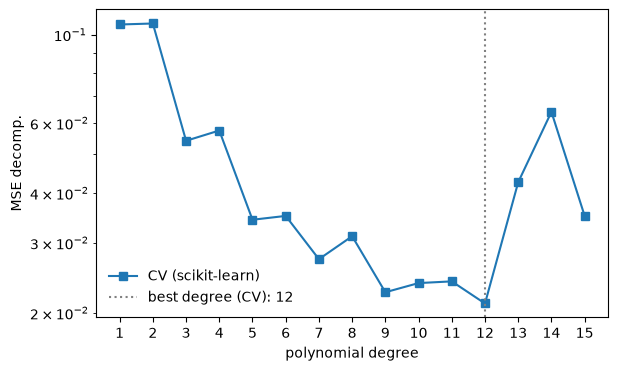

In [14]:
#plot
# plotting MSE and R^2 
best = int(np.argmin(mse_sklearn[:,0]))
best_index = np.argmin(mse_sklearn[:,0])
best_d = list(degrees)[best_index]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(degrees, mse_sklearn[:,0], "s-", label="CV (scikit-learn)")
ax.axvline(
    best_d,
    color="gray",
    linestyle=":",
    label=f"best degree (CV): {best_d}",
)
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomp.")
ax.set_xticks(degrees)
ax.legend(frameon=False)
#plt.savefig(PLOT_DIR / "OLS_MSE_vs_degree.png", dpi=300, bbox_inches="tight")
plt.show()

##### Ridge

In [15]:
# Your code for part d) here

#define lambdas (for Ridge only)
nlambdas = 20 # the number of different lambdas
lambdas = np.logspace(-6, 5, nlambdas)

# initialize result-array (for each degree, lambda and k-fold)
mse_sklearn = np.zeros((maxdegree, nlambdas, len(k)))

# loop over number of folds (k)
for k_idx in range(len(k)):
    kfold = KFold(n_splits=k[k_idx], shuffle=True, random_state=2026)

    #loop over the degrees
    for degree in range(maxdegree):
        poly = PolynomialFeatures(degree=degree)

        # scikit-learn: iterate over the folds and lambdas
        for i, lmb in enumerate(lambdas):
            pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Ridge(alpha=lmb))
            scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error")
            mse_sklearn[degree, i, k_idx] = np.mean(-scores)

Best degree: 13, best lambda: 1.438e-05, MSE: 0.0208 for 5-fold CV
Best degree: 13, best lambda: 1.438e-05, MSE: 0.0193 for 10-fold CV


<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Bruker\AppData\Local\Temp\ipykernel_4660\1872991904.py:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.axvline(np.log10(lambdas[l_idx]), color=colors[k_idx], lw=1.5, ls=":", label=f"best $\lambda$ = {lambdas[l_idx]:.3g}")


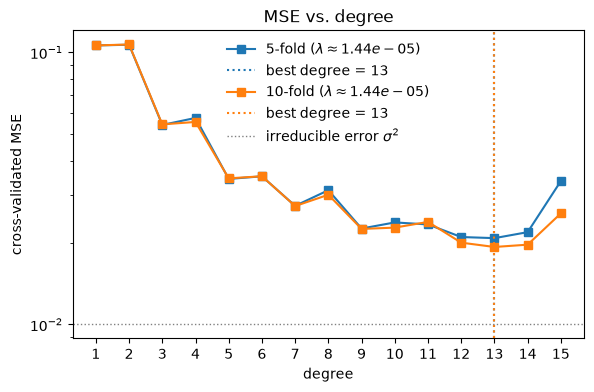

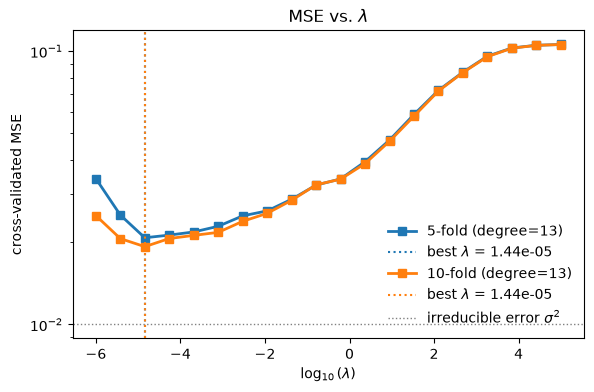

In [16]:
# find the best (degree, lambda) combination for each k
# degrees = np.arange(mse_sklearn.shape[0])          # assumes degree index == degree
best = {}                                          # k -> (degree_idx, lambda_idx)

for k_idx, kk in enumerate(k):
    d_idx, l_idx = np.unravel_index(np.argmin(mse_sklearn[:, :, k_idx]),
                                    mse_sklearn[:, :, k_idx].shape)
    best[kk] = (d_idx, l_idx)
    print(f"Best degree: {degrees[d_idx]}, best lambda: {lambdas[l_idx]:.4g}, "
          f"MSE: {mse_sklearn[d_idx, l_idx, k_idx]:.4f} for {kk}-fold CV")

colors = plt.cm.tab10(np.arange(len(k)))

# --- Plot 1: MSE vs degree (lambda fixed at each k's best lambda) ---
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for k_idx, kk in enumerate(k):
    d_idx, l_idx = best[kk]
    ax.plot(degrees, mse_sklearn[:, l_idx, k_idx], "s-", color=colors[k_idx],
            label=rf"{kk}-fold ($\lambda\approx{lambdas[l_idx]:.3g}$)")
    ax.axvline(degrees[d_idx], color=colors[k_idx], lw=1.5, ls=":", label=f"best degree = {degrees[d_idx]}")
ax.axhline(sigma**2, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("degree")
ax.set_ylabel("cross-validated MSE")
ax.set_title("MSE vs. degree")
ax.set_xticks(degrees)
ax.legend(frameon=False)
#plt.savefig(PLOT_DIR / "Ridge_MSE_vs_degree.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Plot 2: MSE vs lambda (degree fixed at each k's best degree) ---
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for k_idx, kk in enumerate(k):
    d_idx, l_idx = best[kk]
    ax.plot(np.log10(lambdas), mse_sklearn[d_idx, :, k_idx], "s-", color=colors[k_idx],
            lw=2, label=f"{kk}-fold (degree={degrees[d_idx]})")
    ax.axvline(np.log10(lambdas[l_idx]), color=colors[k_idx], lw=1.5, ls=":", label=f"best $\lambda$ = {lambdas[l_idx]:.3g}")
ax.axhline(sigma**2, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("cross-validated MSE")
ax.set_title(r"MSE vs. $\lambda$")
ax.legend(frameon=False)
#plt.savefig(PLOT_DIR / "Ridge_MSE_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()

### Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\theta}$ of OLS and Ridge regression with your own gradient descent
code. In this part we focus only on the simplest gradient descent approach with
a fixed learning rate $\eta$ (see the lectures and exercises of week 37 and
Sections 4.3–4.5 of the lecture notes),

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta\,\nabla_{\boldsymbol{\theta}}C(\boldsymbol{\theta}_k).
$$

Compute the gradient of the cost function in two independent ways:

1. **Analytically**, from the expressions you derived in the week-35 exercises,
   that is $\nabla_{\boldsymbol{\theta}}C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})$
   for OLS and the corresponding expression with the extra term
   $2\lambda\boldsymbol{\theta}$ for Ridge (check your normalization
   conventions).
2. By **automatic differentiation** (Section 4.14 of the lecture notes), using
   for example **JAX** (`jax.grad`) or **Autograd**. Write the cost function as
   an ordinary Python function of $\boldsymbol{\theta}$ and let the library
   produce its gradient.

ToDos:

- $\otimes$ Verify that the two gradients agree to machine precision for OLS and Ridge, and
use both in your gradient descent code.
- Discuss briefly why automatic
differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost
function.

- $\otimes$ Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? 
   - What do we mean by "converge"? -> What tolerance should/ do we want to set?
- Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

The cell below shows the minimal version of the automatic-differentiation check
with JAX (install with `pip install jax jaxlib`). Note the 64-bit switch: JAX
defaults to 32-bit floats, which would hide the "machine precision" agreement.

##### Gradients: AD vs analytic

In [16]:
#OLD, this has different scaling/ centering of data than what we want
# # calculate gradients with AD vs analytic
# import jax
# import jax.numpy as jnp
# jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

# degree, lmbda = 5, 1e-2
# X = design_matrix(x, degree, intercept=False) 
# # intercept = false means we have to center y
# y_mean = y.mean()
# y_centered = (y - y_mean)
# theta0 = rng.normal(size=X.shape[1])
# def cost_ols(theta, X, y):
#     return jnp.mean((y - X @ theta)**2)

# def cost_ridge(theta, X, y, lmbda):
#     return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# # gradients by automatic differentiation (with respect to argument 0 = theta)
# grad_ols_ad = jax.grad(cost_ols)
# grad_ridge_ad = jax.grad(cost_ridge)

# # the same gradients by hand
# grad_ols_analytic = 2.0 / len(y_centered) * X.T @ (X @ theta0 - y_centered)
# grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

# print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y_centered) - grad_ols_analytic)))
# print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y_centered, lmbda) - grad_ridge_analytic)))

# # the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
# H = 2.0 / len(y_centered) * X.T @ X
# print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

In [17]:
# calculate gradients with AD vs analytic
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

# parameters 
degree, lmbda = 5, 1e-2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(x_train.reshape(-1,1))
scaler = StandardScaler().fit(X_train_poly)
X = scaler.transform(X_train_poly)     # zero-mean, unit-variance columns
y_centered = np.asarray(y_train).ravel() - np.mean(y_train)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y_centered) * X.T @ (X @ theta0 - y_centered)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y_centered) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y_centered, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y_centered) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

H_ridge = H + 2 * lmbda * np.eye(X.shape[1])
print("eta_max for Ridge  =", 2.0 / np.linalg.eigvalsh(H_ridge).max())


OLS   max |AD - analytic| = 8.881784197001252e-16
Ridge max |AD - analytic| = 8.881784197001252e-16
eta_max for OLS  = 0.3595749913963397
eta_max for Ridge  = 0.35828668209004005


In [20]:
# define analytic gradient function 
def grad_analytic(theta,  X, y, lmbda="0.0"):
    """Returns the analytical gradient for Ridge regression for a given lambda (or OLS for lmbda=0)."""
    return 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lmbda * theta

##### Define a function that can do it all 

In [21]:
def gradient_descent(X, y, num_iters, lrates=[0.1], tol=1e-8, method= "OLS", lmbda=0.0):
    """Returns the gradient descent parameters as well as difference to the closed form solutions for the selected methods using both analytical and automatic differentiation.
    Inputs:
        X: Design matrix.
        y: What even is this called?
        num_iters: Max. number of iterations that is made before breaking off.
        lrates: Array of learning rates eta that are tried. Default 0.1.
        tol: The tolerance that is tried to be reached. Default 1e-8.
        method: OLS or Ridge
        lmbda: The penalty parameter for Ridge

    Returns:
        iterates_analytic: array containing all iterates theta_k for each lrate and iteration cycle for gradient descent using analytical differentiation.
        iterates_ad: array containing all iterates theta_k for each lrate and iteration cycle for gradient descent using automatic differentiation.
        dist_analytic: The distance of the gradient descent values obtained using analytical differentiation from the closed form solution
        dist_ad: The distance of the gradient descent values obtained using automatic differentiation from the closed form solution

    """
    # Gradient descent parameters
    lrates = lrates

    # get the closed form results from a) (OLS) and b) (Ridge)
    closed_form= model_creator(x_train, x_test, y_train, y_test, degree, method=method, lmbda=lmbda)[2]
    n_features = len(closed_form)

    #initialize arrays for plotting with one column for the iteration number and one for the gradient descent coefficients
    iterates_analytic = np.zeros((num_iters, n_features, len(lrates)))
    iterates_ad = np.zeros((num_iters, n_features, len(lrates)))
    dist_analytic = np.zeros((num_iters, len(lrates)))
    dist_ad = np.zeros((num_iters, len(lrates)))

    # loop over different lrates
    for i in range(len(lrates)):
        # get lrate value
        lrate_val = lrates[i]

        # (re-)initialize weights for gradient descent
        theta_analytic = np.zeros((n_features, len(lrates)))
        theta_ad = np.zeros((n_features, len(lrates)))

        # initialize the distance ONCE per lrate, before the loop
        dist_analytic[0,i] = np.linalg.norm(theta_analytic[:, i] - closed_form)

        # loop over GD iterations
        for t in range(num_iters):
            if dist_analytic[t,i] > tol:
                # iteration step for analytic
                theta_analytic[:, i] = theta_analytic[:, i] - lrate_val * grad_analytic(theta_analytic[:, i], X, y, lmbda=lmbda)

                # iteration step for ad
                if method == "OLS":
                    theta_ad[:, i] = theta_ad[:, i] - lrate_val * grad_ols_ad(theta_ad[:, i], X, y)
                elif method == "Ridge":
                    theta_ad[:, i] = theta_ad[:, i] - lrate_val * grad_ridge_ad(theta_ad[:, i], X, y, lmbda)
                else:
                    raise ValueError("Method must be 'OLS' or 'Ridge'.")

                # store iterates in case they are needed
                iterates_analytic[t, :, i] = theta_analytic[:, i]
                iterates_ad[t, :, i] = theta_ad[:, i]

                # calculate new distance
                if t + 1 < num_iters:
                    dist_analytic[t+1,i] = np.linalg.norm(theta_analytic[:, i] - closed_form)
                    dist_ad[t+1,i] = np.linalg.norm(theta_ad[:, i] - closed_form)
            else:
                print(method,": for lrate", lrate_val, " tolerance (analytic) reached at iteration number ", t)
                break
    return iterates_analytic, iterates_ad, dist_analytic, dist_ad

##### OLS

In [22]:
# GD for OLS
# define parameters
eta_max_ols = 2.0 / np.linalg.eigvalsh(H).max()
learning_rates = np.linspace(0.1, 0.99*eta_max_ols, 5)
lrates_ols = np.linspace(0.1, 0.99*eta_max_ols, 5)
num_iters_ols = 10000
tol_ols = 1e-8

# run the function
ols_gradient_descent = gradient_descent(X, y_centered, num_iters_ols, lrates_ols, tol=tol_ols, method= "OLS", lmbda=0.0)

OLS : for lrate 0.16399481037059407  tolerance (analytic) reached at iteration number  9170
OLS : for lrate 0.22798962074118814  tolerance (analytic) reached at iteration number  6594
OLS : for lrate 0.2919844311117822  tolerance (analytic) reached at iteration number  5147
OLS : for lrate 0.3559792414823763  tolerance (analytic) reached at iteration number  4220


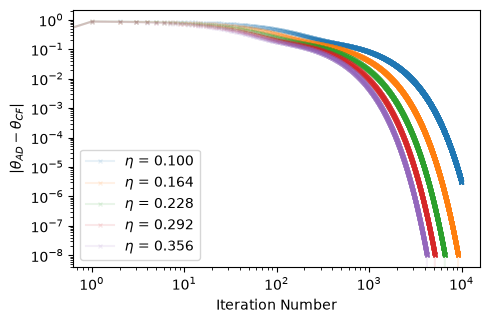

In [23]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5/1.5))

# ax.set_title("")
ax.set_xlabel("Iteration Number")
ax.set_ylabel("|$\\theta_{AD} - \\theta_{CF}$|")
for i in range(len(lrates_ols)):
    #ax.loglog(ols_gradient_descent[2][:, i], label=f'OLS, analytical $\\eta$={lrates_ols[i]}', marker='o', alpha=0.1, markersize=3)
    ax.loglog(ols_gradient_descent[3][:, i], label=f'$\\eta$ = {lrates_ols[i]:.3f}', marker='x', alpha= 0.1, markersize=3)
ax.legend()
#plt.savefig(PLOT_DIR / "OLS_gradient_descent.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# # plot
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# ax.set_title("OLS: Distance between GD iterations using analytical vs. automatic differentiation")
# ax.set_xlabel("Iteration Number")
# ax.set_ylabel("Mean difference between AD and AN")
# # ax.set_ylim(0, 100)
# for i in range(len(lrates_ols)):
#     diff = np.abs(ols_gradient_descent[0][:, i] - ols_gradient_descent[1][:, i])
#     ax.plot(diff.mean(axis=1), label=f'OLS, $\\eta$={lrates_ols[i]}', marker='o', markersize = 1)
# ax.legend()
# ax.set_ylim(1e-16, -1e-16)
# plt.tight_layout()
# plt.show()

##### Ridge

In [24]:
# GD for Ridge
# define parameters
eta_max_ridge = 2.0 / np.linalg.eigvalsh(H_ridge).max()
lmbda = 1.438e-05 #the "perfect" lambda that came out of our cross-validation in part d)
lrates_ridge = np.linspace(0.1, 0.99*eta_max_ridge, 5)
num_iters_ridge = 10000
tol_ridge = 1e-8

# run the function
ridge_gradient_descent = gradient_descent(X, y_centered, num_iters_ridge, lrates_ridge, tol=tol_ridge, method= "Ridge", lmbda=0.0)

Ridge : for lrate 0.16367595381728492  tolerance (analytic) reached at iteration number  9188
Ridge : for lrate 0.22735190763456983  tolerance (analytic) reached at iteration number  6612
Ridge : for lrate 0.2910278614518548  tolerance (analytic) reached at iteration number  5164
Ridge : for lrate 0.35470381526913963  tolerance (analytic) reached at iteration number  4235


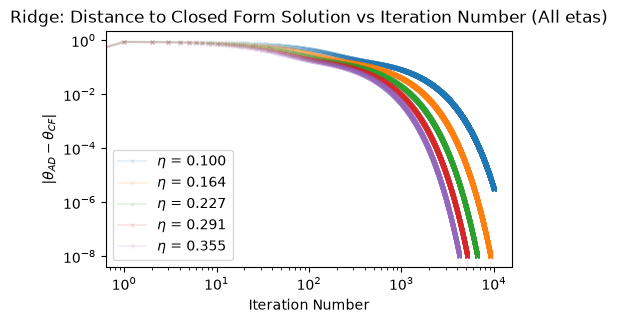

In [25]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5/1.5))

ax.set_title("Ridge: Distance to Closed Form Solution vs Iteration Number (All etas)")
ax.set_xlabel("Iteration Number")
ax.set_ylabel("|$\\theta_{AD} - \\theta_{CF}$|")
for i in range(len(lrates_ridge)):
    #ax.loglog(ridge_gradient_descent[2][:, i], label=f'Ridge, analytical $\\eta$={lrates_ridge[i]}', marker='o', alpha=0.1, markersize=3)
    ax.loglog(ridge_gradient_descent[3][:, i], label=f'$\\eta$ = {lrates_ridge[i]:.3f}', marker='x', alpha= 0.1, markersize=3)
ax.legend()
#plt.savefig(PLOT_DIR / "Ridge_gradient_descent.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# # plot
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# ax.set_title("Ridge: Distance between GD iterations using analytical vs. automatic differentiation")
# ax.set_xlabel("Iteration Number")
# ax.set_ylabel("Mean difference between AD and AN")
# # ax.set_ylim(0, 100)
# for i in range(len(lrates_ridge)):
#     diff = np.abs(ridge_gradient_descent[0][:, i] - ridge_gradient_descent[1][:, i])
#     ax.plot(diff.mean(axis=1), label=f'OLS, $\\eta$={lrates_ridge[i]}', marker='o', markersize = 1)
# ax.legend()
# ax.set_ylim(1e-16, -1e-16)
# #plt.savefig(PLOT_DIR / "Ridge_gradient_descent.png", dpi=300, bbox_inches="tight")
# plt.tight_layout()
# plt.show()

### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

Eq. **(4.17)** gives the Hessian : $H = \frac{2}{n}X^TX + 2\lambda I.$

For a quadratic cost, the difference between the cost at the current point $ \theta$  and at the exact minimum $ \theta^*$ in  eq . **(4.22)**can be written in the matrix form  as $C(\theta)-C(\theta^*) = \frac{1}{2}(\theta-\theta^*)^T H(\theta-\theta^*).$

 we define: $e = \theta-\theta^*,$ and substitute Eq. **(4.17)**, we get : $ C(\theta)-C(\theta^*) =\frac{1}{n}e^TX^TXe+\lambda e^Te.$

Since:  $e^TX^TXe = \|Xe\|^2$
and $e^Te = \|e\|^2,$
,we get  $C(\theta)-C(\theta^*)=\frac{1}{n}\|Xe\|^2+\lambda\|e\|^2.$

It is later used as a reference for measuring the difference between $ \theta $ and  $ \theta^* $. $\frac{C(\theta_t)-C(\theta^*)}{C(\theta_0)-C(\theta^*)}$ , So at the beginning, the relative gap will be $\frac{C(\theta_0)-C(\theta^*)}{C(\theta_0)-C(\theta^*)}=1$.

In [26]:
# Your code for part f) here
optimizer_degrees = [5, 8, 15] # Polynomial degrees we will  test
base_rates = np.logspace(-4, 0, 9)#the Initial learning rates to test

optimizer_tolerance=1e-4 # how acuurate the convergence 
optimizer_max_iters =  20000
ridge_lmbda = 0.1

def prepare_polynomial(x_train, x_test, y_train, degree):
    raw_train = design_matrix(np.asarray(x_train).reshape(-1), degree, intercept=False)
    raw_test = design_matrix(np.asarray(x_test).reshape(-1), degree, intercept=False)
    scaler = StandardScaler().fit(raw_train)
    y_flat = np.asarray(y_train).reshape(-1)
    return dict(X=scaler.transform(raw_train), X_test=scaler.transform(raw_test), y=y_flat - y_flat.mean(), y_mean=y_flat.mean(), mu=scaler.mean_, sd=scaler.scale_)

def closed_form_solution(X, y, lmbda=0.0):
    y = np.asarray(y).reshape(-1)
    if lmbda == 0.0:
        return np.linalg.lstsq(X, y, rcond=None)[0]
    return np.linalg.solve(X.T @ X + len(y) * lmbda * np.eye(X.shape[1]), X.T @ y)

def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99, beta1=0.9, beta2=0.999, eps=1e-08):
    if method == 'plain':
        return (theta - gamma * g, state)
    if method == 'momentum':
        state['v'] = v = beta * state.get('v', 0.0) + gamma * g
        return (theta - v, state)
    if method == 'adagrad':
        state['r'] = r = state.get('r', 0.0) + g * g
        return (theta - gamma * g / (np.sqrt(r) + eps), state)
    if method == 'rmsprop':
        state['r'] = r = rho * state.get('r', 0.0) + (1.0 - rho) * g * g
        return (theta - gamma * g / (np.sqrt(r) + eps), state)
    if method == 'adam':
        state['m'] = m = beta1 * state.get('m', 0.0) + (1.0 - beta1) * g
        state['r'] = r = beta2 * state.get('r', 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = (m / (1.0 - beta1 ** t), r / (1.0 - beta2 ** t))
        return (theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state)
    raise ValueError(f'unknown method {method}')

def regression_cost(theta, X, y, lmbda=0.0):
    return np.mean((np.asarray(y).ravel() - X @ theta)**2) + lmbda * np.sum(theta**2)


In [27]:
def run_optimizer(X, y, lmbda, method, gamma, theta_ref, tolerance=1e-4, max_iters=20000):
    """
    Starts from theta_0, calculates the gradient, updates theta using
    the selected optimization method, and stops when the tolerance is reached.
    """
    theta = np.zeros(X.shape[1])
    state = {} # information from previous iterations .New velocity for each independent step.
    reference_cost = regression_cost(theta_ref, X, y, lmbda)
    initial_error = regression_cost(theta, X, y, lmbda) - reference_cost
    relative_gaps = [1.0] # this gap must be decreasing after each step .
    status = "budget"

    for t in range(1, max_iters + 1):
        g = grad_analytic(theta, X, y, lmbda) # Calculate the  gradient at the current theta
        theta, state = optimiser_step(method, theta, g, state, t, gamma) # Update theta using the  optimization method

        relative_gap = max(0.0, regression_cost(theta, X, y, lmbda) - reference_cost) / initial_error
        relative_gaps.append(relative_gap)
        if not np.isfinite(relative_gap) or relative_gap > 1e12:
            status = "unstable"
            break
        if relative_gap <= tolerance:
            status = "target met"  # First hit; this does not prove future stability.
            break

    return {"method": method, "gamma": float(gamma), "theta": theta,
            "iterations": t,"status": status, "relative_gap": float(relative_gaps[-1]),
            "history": np.asarray(relative_gaps)}

In [28]:
def compare_optimizers(x_train, x_test, y_train, y_test, degrees, ridge_lmbda, rates,
            tolerance=1e-4, max_iters=20000):
    """
    Store  results from all steps.
    """
    cases = []
    methods = ("plain", "momentum", "adagrad", "rmsprop", "adam")

    for degree in degrees:# in part d,  degrees = range(maxdegree)
        prepared = prepare_polynomial(x_train, x_test, y_train, degree)
        X, X_test, y = prepared["X"], prepared["X_test"], prepared["y"]

        for model, lmbda in (("OLS", 0.0), ("Ridge", ridge_lmbda)):
            theta_ref = closed_form_solution(X, y, lmbda)
            reference_test = prepared["y_mean"] + X_test @ theta_ref

            case = {"degree": degree, "model": model, "lmbda": lmbda, "prepared": prepared,
                    "theta_ref": theta_ref,
                    "reference_cost": regression_cost(theta_ref, X, y, lmbda),
                    "reference_test_mse": float(np.mean((y_test - reference_test) ** 2)), "runs": []}
            for method in methods:# try all optimization methods and learning rates
                for gamma in rates:
                    result = run_optimizer(X, y, lmbda, method, gamma, theta_ref, tolerance, max_iters)
                    prediction = prepared["y_mean"] + X_test @ result["theta"]
                    result["test_mse"] = float(np.mean((y_test - prediction) ** 2))
                    case["runs"].append(result)

            cases.append(case)
            print(f"Finished {model}, degree {degree}: {len(case['runs'])} runs", flush=True)

    return cases

In [29]:
def print_optimizer_results(cases):
    for case in cases:
        print("\n", case["model"], "degree", case["degree"], "lambda", case["lmbda"])
        print("Updates to target; -- means the target was not reached.")
        print("Rate      ", end="")
        for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
            print(f"{method:>12s}", end="")
        print()
        for gamma in base_rates:
            print(f"{gamma:9.4g} ", end="")
            for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
                for result in case["runs"]:
                    if result["method"] == method and result["gamma"] == gamma:
                        value = str(result["iterations"]) if result["status"] == "target met" else "--"
                        print(f"{value:>12s}", end="")
            print()

In [30]:
def plot_optimizer_results(cases, rates, tolerance, max_iters):
    degrees = [5, 8, 15]

    for degree in degrees:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        degree_cases = [case for case in cases if case["degree"] == degree]

        for index, case in enumerate(degree_cases):
            ax = axes[index]

            for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
                counts = []

                for result in case["runs"]:
                    if result["method"] == method:
                        counts.append(result["iterations"] if result["status"] == "target met" else np.nan)

                ax.loglog(rates, counts, "o-", label=method)

            ax.set_title(case["model"] + ", degree " + str(case["degree"]))
            ax.set_xlabel("Learning rate")
            ax.set_ylabel("Updates to relative cost gap <= 1e-4")
            ax.legend(fontsize=8)

        fig.suptitle("Degree " + str(degree) + " — Missing points: target not reached within the update budget")
        fig.tight_layout()
        fig.savefig(f"optimizer_results_degree_{degree}.pdf", format="pdf", bbox_inches="tight")
        plt.show()

In [31]:
optimizer_cases = compare_optimizers(x_train, x_test, y_train.ravel(), y_test.ravel(),optimizer_degrees, ridge_lmbda, base_rates,
    tolerance=optimizer_tolerance, max_iters=optimizer_max_iters,)


print_optimizer_results(optimizer_cases)

Finished OLS, degree 5: 45 runs
Finished Ridge, degree 5: 45 runs
Finished OLS, degree 8: 45 runs
Finished Ridge, degree 8: 45 runs
Finished OLS, degree 15: 45 runs
Finished Ridge, degree 15: 45 runs

 OLS degree 5 lambda 0.0
Updates to target; -- means the target was not reached.
Rate             plain    momentum     adagrad     rmsprop        adam
   0.0001           --          --          --        7281       11833
0.0003162           --          --          --        2582        5934
    0.001           --       17897          --        1040        2722
 0.003162           --        5653          --         481        1007
     0.01        17907        1781       10100          --         342
  0.03162         5662         556        1322          --         171
      0.1         1790         169         958          --         182
   0.3162          566          73         982          --         192
        1           --          --         986          --         193

 Ridge 

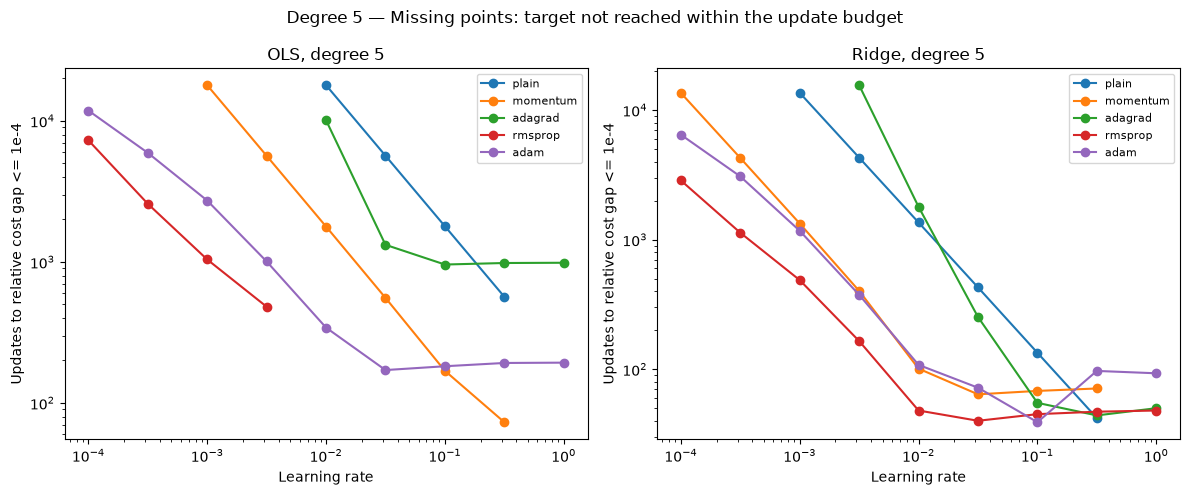

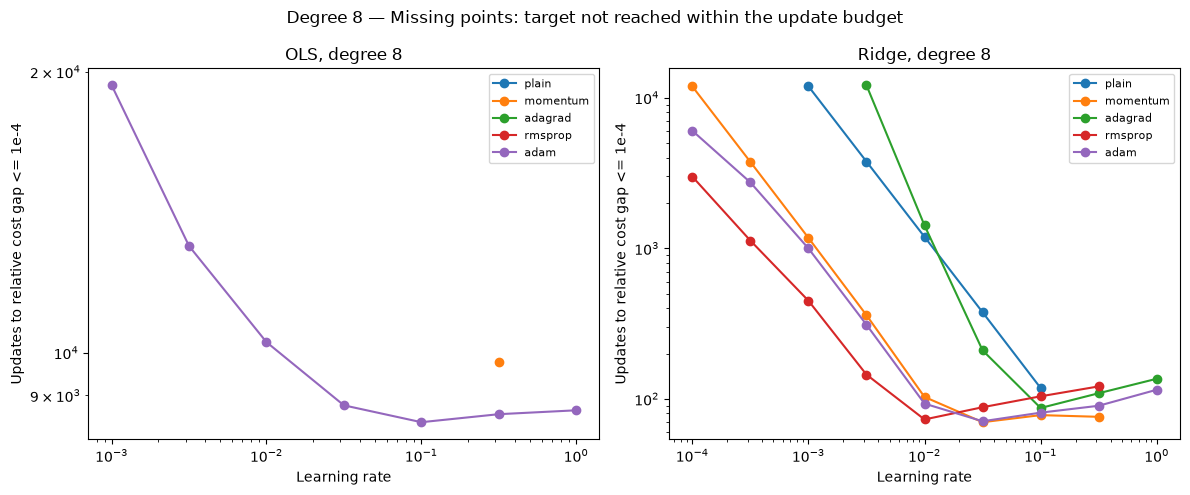

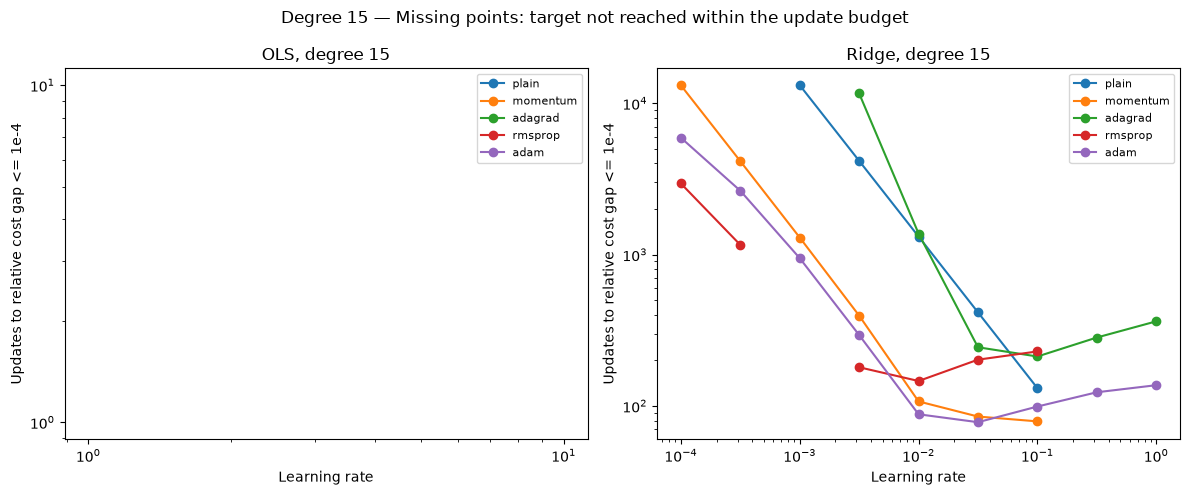

In [32]:
#=============Plot ===============================
optimizer_rates_figure = plot_optimizer_results(optimizer_cases, base_rates, optimizer_tolerance, optimizer_max_iters)

In [71]:
#for case in optimizer_cases:
   #if case["model"] == "OLS" and case["degree"] == 15:
       # for result in case["runs"]:
           # print(result["method"], result["gamma"], result["status"], result["iterations"], result["relative_gap"])

In [35]:
import pandas as pd
rows = []
for case in optimizer_cases:
    if case["model"] == "OLS" and case["degree"] == 15:
        for result in case["runs"]:
            rows.append({"Method": result["method"],"Learning rate": f"{result['gamma']:.4g}",
                "Status": result["status"],"Iterations": result["iterations"],
                "Relative gap": f"{result['relative_gap']:.3e}"})
df_ols15 = pd.DataFrame(rows)
print(df_ols15.to_string(index=False))

  Method Learning rate   Status  Iterations Relative gap
   plain        0.0001   budget       20000    3.915e-01
   plain     0.0003162   budget       20000    3.149e-01
   plain         0.001   budget       20000    2.390e-01
   plain      0.003162   budget       20000    1.905e-01
   plain          0.01   budget       20000    1.536e-01
   plain       0.03162   budget       20000    1.019e-01
   plain           0.1   budget       20000    7.410e-02
   plain        0.3162 unstable          10    6.500e+12
   plain             1 unstable           6    8.837e+13
momentum        0.0001   budget       20000    2.390e-01
momentum     0.0003162   budget       20000    1.906e-01
momentum         0.001   budget       20000    1.536e-01
momentum      0.003162   budget       20000    1.019e-01
momentum          0.01   budget       20000    7.410e-02
momentum       0.03162   budget       20000    5.812e-02
momentum           0.1   budget       20000    4.236e-02
momentum        0.3162 unstable

### Part g): Writing our own code for Lasso regression

Lasso regression (Section 3.9 of the lecture notes, and the lectures of weeks 35
and 36) represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts e) and f)
to solve the Lasso optimization problem.

The $\ell_1$ penalty $\lambda\|\boldsymbol{\theta}\|_1$ is not differentiable
at $\theta_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\theta|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

####  The Lasso cost and the value at zero

With the same scaled design matrix and centred training targets as in f, we minimise

$$C_L(\theta)=\frac{1}{n}\|X\theta-y_c\|_2^2+\lambda\sum_j|\theta_j|,\qquad \lambda\ge0. \qquad\text{Eq. (3.57)}$$

The intercept is handled through the training target mean, Eq. **(3.90)**, and is not part of the penalty. Predictions remain $\bar y_{\rm train}+X_{\rm test}\theta$.

Away from zero, $d|\theta_j|/d\theta_j=\operatorname{sign}(\theta_j)$, Eq. **(3.58)**. At zero the ordinary derivative does not exist. The allowed subgradients are

$$s_j=\begin{cases}+1,&\theta_j>0,\\-1,&\theta_j<0,\\\text{any value in }[-1,1],&\theta_j=0,\end{cases}\qquad\text{Eq. (3.65)}$$

so a subgradient of the complete cost is

$$g_L(\theta)=\frac{2}{n}X^T(X\theta-y_c)+\lambda s.$$

This combines the OLS gradient **(4.13)** with **(3.65)**. It is the mean-squared-error version of **(3.59)**

In [36]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0


In [37]:
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3))
print( "jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0
jax.grad(jnp.abs)(0.3) = 1.0


In [38]:
def lasso_cost(theta, X, y, lmbda):
    
    return regression_cost(theta, X, y, lmbda=0.0) + lmbda * np.sum(np.abs(theta))# Eq (3.57)


def lasso_subgradient(theta, X, y, lmbda, zero_choice=0.0):# Eqs. (3.58), (3.65), with the 1/n factor
    if not -1.0 <= zero_choice <= 1.0:
        raise ValueError('The subgradient of abs at zero must lie in [-1, 1].')
    signs = np.where(theta == 0.0, zero_choice, np.sign(theta))  # Eq. (3.65).
    return grad_analytic(theta, X, y, lmbda=0.0) + lmbda * signs

In [39]:
def run_lasso(X, y, lmbda, method, gamma, theta_ref, tolerance=1e-4, max_iters=20000):
    """
    Instead of the OLS/Ridge gradient, we use the Lasso subgradient,
    and  run one Lasso optimization experiment using one 
    specific method and one specific learning rate.we calculate the cost difference directly 
    instead of using the quadratic excess_cost().
    """
    theta = np.zeros(X.shape[1])
    state = {}
    reference_cost = lasso_cost(theta_ref, X, y, lmbda)
    initial_gap = lasso_cost(theta, X, y, lmbda) - reference_cost
    if initial_gap <= 1e-14:
        return dict(method=method, gamma=float(gamma), theta=theta, iterations=0,
                    status='target met', relative_gap=0.0, history=np.array([0.0]))
    history = [1.0]
    status = 'budget'
    for t in range(1, max_iters + 1):
        gradient = lasso_subgradient(theta, X, y, lmbda)
        theta, state = optimiser_step(method, theta, gradient, state, t, gamma)
        relative_gap = (lasso_cost(theta, X, y, lmbda) - reference_cost) / initial_gap  # (G.1).
        relative_gap = max(float(relative_gap), 0.0)  # Ignore a tiny negative round-off error.
        history.append(relative_gap)
        if not np.isfinite(relative_gap) or relative_gap > 1e12:
            status = 'unstable'
            break
        if relative_gap <= tolerance:
            status = 'target met'
            break
    return dict(method=method, gamma=float(gamma), theta=theta, iterations=t,
                status=status, relative_gap=history[-1], history=np.asarray(history))

In [40]:
from sklearn.linear_model import Lasso

def compare_lasso(degrees, penalties, rates, tolerance=1e-4, max_iters=20000):
    """ will run the Lasso experiments for: different polynomial degrees , different Lasso penalties
    ,different learning rates, a chosen tolerance ,a maximum number of iterations
    """
    cases = []
    for degree in degrees:
        prepared = prepare_polynomial(x_train, x_test, y_train.ravel(), degree)
        """
        X : training design matrix, X_test:test design matrix, y:training target
        """
        X, X_test, y = prepared['X'], prepared['X_test'], prepared['y']
        for lmbda in penalties:
            reference_model = Lasso(alpha=lmbda / 2, fit_intercept=False, max_iter=200000, tol=1e-12)
            reference_model.fit(X, y)
            theta_ref = reference_model.coef_
            reference_prediction = prepared['y_mean'] + X_test @ theta_ref  #eq  (3.90).
            case = dict(degree=degree, model='Lasso', lmbda=float(lmbda), 
                        prepared=prepared, theta_ref=theta_ref, 
                        reference_cost=lasso_cost(theta_ref, X, y, lmbda),
                        reference_test_mse=float(np.mean((y_test.ravel()-reference_prediction)**2)),
                        runs=[])
            for method in ('plain', 'momentum', 'adagrad', 'rmsprop', 'adam'):
                for gamma in rates:
                    result = run_lasso(X, y, lmbda, method, gamma, theta_ref, tolerance, max_iters)
                    prediction = prepared['y_mean'] + X_test @ result['theta']
                    result['test_mse'] = float(np.mean((y_test.ravel()-prediction)**2))  # (3.6).
                    case['runs'].append(result)
            cases.append(case)
    return cases

In [41]:
def print_lasso_results(cases, earlier_cases):
    """ suggested by "Chatgpt5.6 sol" .
    """
    print("Lowest final training cost gap among the tested rates; test MSE does not select the rate.")
    print("Degree Model Lambda Method Rate Updates Gap Test MSE")
    for case in earlier_cases + cases:
        for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
            best = None
            for result in case["runs"]:
                if result["method"] == method:
                    if best is None or result["relative_gap"] < best["relative_gap"]:
                        best = result
            print("Degree:", case["degree"], "| Model:", case["model"], 
                  "| Lambda(penalty):", case["lmbda"], "| Method:", method, "| Gamma(learning rate):",
                  f"{best['gamma']:.4g}", "| Iterations:", best["iterations"], "| Relative gap:",
                  f"{best['relative_gap']:.3e}", "| Test MSE:", f"{best['test_mse']:.6f}")
            

In [43]:
def plot_lasso_results(cases, tolerance):
    lambdas = [0.001, 0.01, 0.1]
    degrees = [5, 8, 15]
    figs = []

    for lmbda in lambdas:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

        for index, degree in enumerate(degrees):
            ax = axes[index]
            case = next(case for case in cases if case["degree"] == degree and np.isclose(case["lmbda"], lmbda))

            for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
                rates = []
                gaps = []

                for result in case["runs"]:
                    if result["method"] == method:
                        rates.append(result["gamma"])
                        gaps.append(result["relative_gap"])

                ax.loglog(rates, gaps, "o-", label=method)

            X = case["prepared"]["X"]
            hessian = 2.0 / len(X) * X.T @ X
            rate_limit = 2.0 / np.linalg.eigvalsh(hessian).max()
            ax.axvline(rate_limit, color="gray", linestyle="--", linewidth=1,
                       label=r"Smooth-loss GD bound $2/\lambda_{\max}$")
            ax.axhline(tolerance, color="gray", linestyle=":")
            ax.set_title("Degree " + str(degree) + ", lambda=" + str(lmbda))
            ax.set_xlabel("Learning rate")
            ax.set_ylabel("Final relative Lasso cost gap")
            ax.legend(fontsize=7)
            # ax.axvline(2 / eigs6.max(), color=GREY, ls="--", lw=1, label=r"$2/\lambda_{\max}$")

        fig.suptitle("Lasso results for lambda=" + str(lmbda))
        fig.tight_layout()
        fig.savefig("plot_lasso_results_lambda_" + str(lmbda).replace(".", "p") + ".pdf", format="pdf", bbox_inches="tight")
        plt.show()
        figs.append(fig)

    return figs

In [45]:
lasso_penalties = [0.001, 0.01, 0.1]
lasso_cases = compare_lasso(optimizer_degrees, lasso_penalties, base_rates,
                            tolerance=optimizer_tolerance, max_iters=optimizer_max_iters)
print_lasso_results(lasso_cases, optimizer_cases)


Lowest final training cost gap among the tested rates; test MSE does not select the rate.
Degree Model Lambda Method Rate Updates Gap Test MSE
Degree: 5 | Model: OLS | Lambda(penalty): 0.0 | Method: plain | Gamma(learning rate): 0.3162 | Iterations: 566 | Relative gap: 9.947e-05 | Test MSE: 0.036359
Degree: 5 | Model: OLS | Lambda(penalty): 0.0 | Method: momentum | Gamma(learning rate): 0.3162 | Iterations: 73 | Relative gap: 9.637e-05 | Test MSE: 0.036483
Degree: 5 | Model: OLS | Lambda(penalty): 0.0 | Method: adagrad | Gamma(learning rate): 0.03162 | Iterations: 1322 | Relative gap: 9.953e-05 | Test MSE: 0.036715
Degree: 5 | Model: OLS | Lambda(penalty): 0.0 | Method: rmsprop | Gamma(learning rate): 0.003162 | Iterations: 481 | Relative gap: 9.788e-05 | Test MSE: 0.036497
Degree: 5 | Model: OLS | Lambda(penalty): 0.0 | Method: adam | Gamma(learning rate): 0.03162 | Iterations: 171 | Relative gap: 9.663e-05 | Test MSE: 0.036352
Degree: 5 | Model: Ridge | Lambda(penalty): 0.1 | Method:

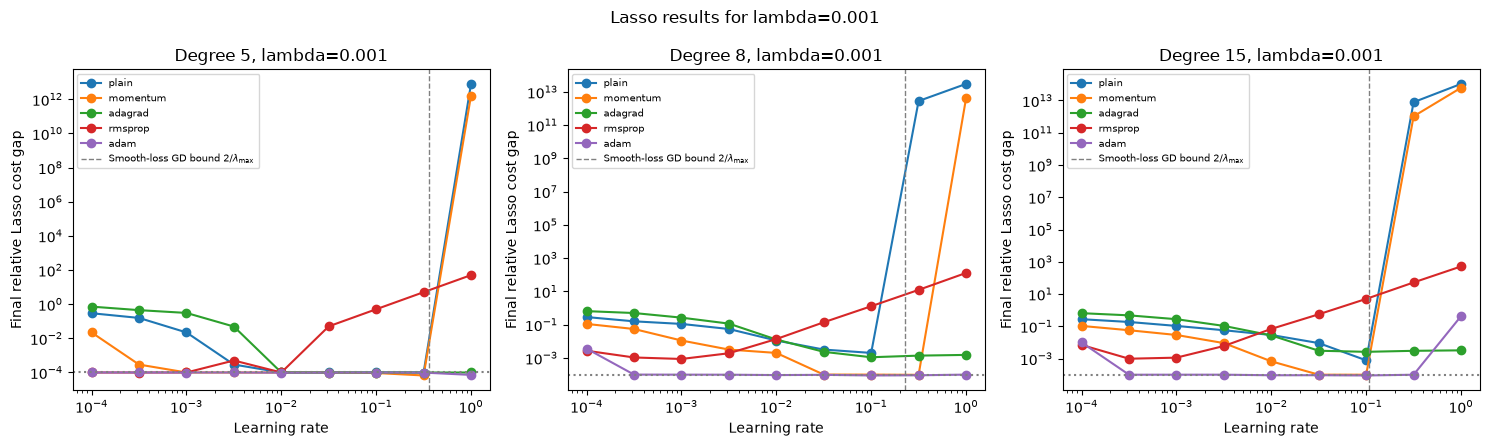

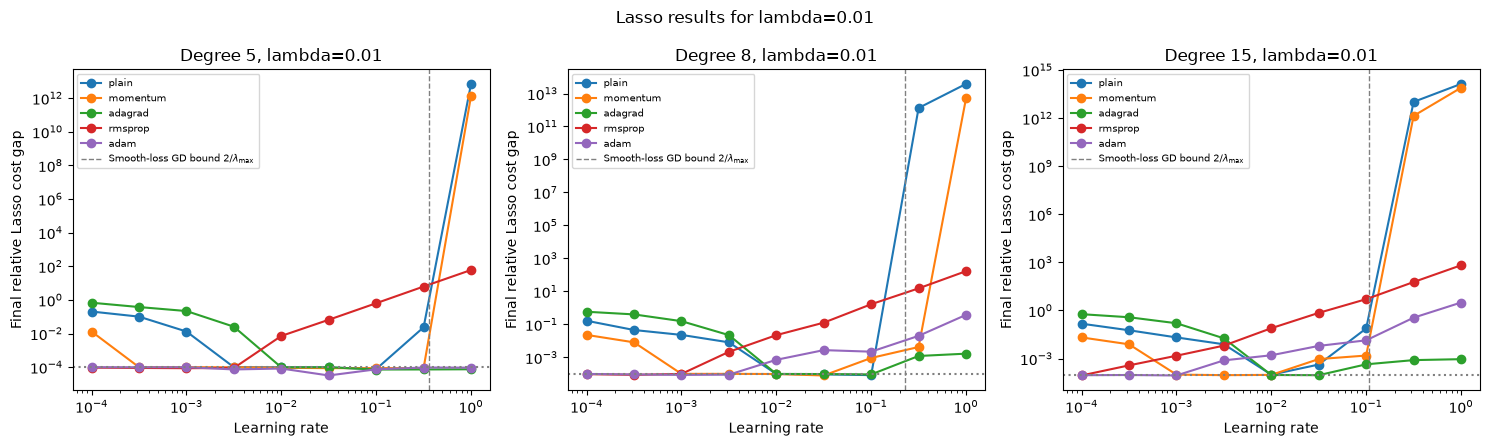

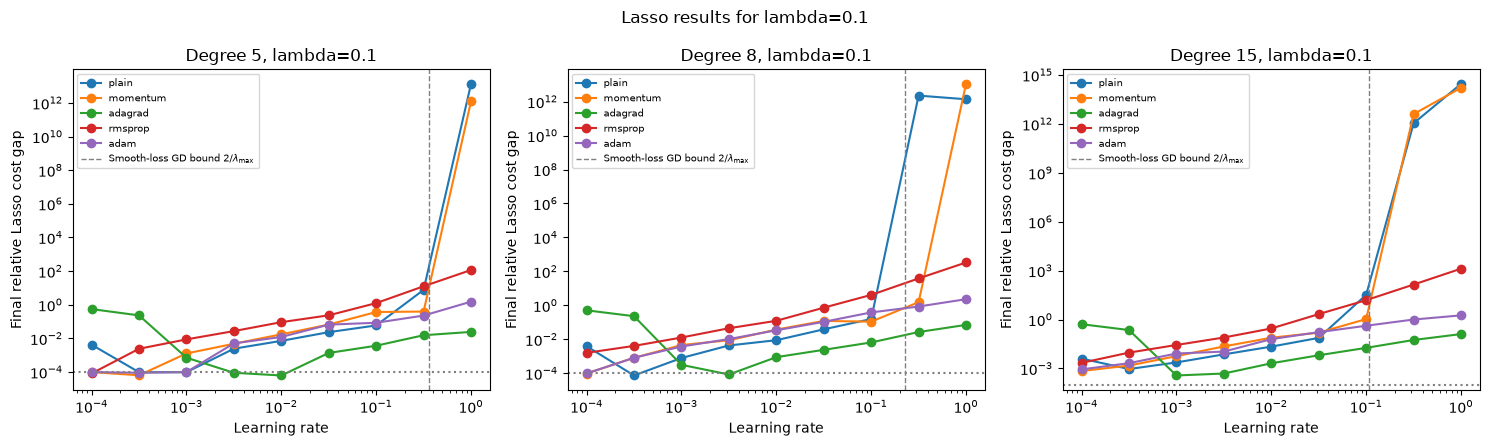

In [72]:
lasso_convergence_figure = plot_lasso_results(lasso_cases, optimizer_tolerance)

### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

For a batch $B$ of actual size $|B|$, the mean-squared-error gradients are

$$g_B^{\rm OLS}(\theta)=\frac{2}{|B|}X_B^T(X_B\theta-y_B),$$
$$g_B^{\rm Ridge}(\theta)=g_B^{\rm OLS}(\theta)+2\lambda\theta,$$
$$g_B^{\rm Lasso}(\theta)=g_B^{\rm OLS}(\theta)+\lambda s(\theta),\quad s_j=\operatorname{sign}(\theta_j),\ s_j(0)=0.$$

In [79]:
# Your code for part h) here

In [75]:
from time import perf_counter

def make_batches(n, batch_size, rng):# Shuffle the indices and split them into minibatches
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):# learning rate : Eq. (4.40).
    return t0/(t+t1)


def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1,#stochastic gradient descent 
              schedule=None, lmbda=0.0, seed=2026, gradient=None,
              **kw):
    
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p)# Start with theta = 0
    state = {}
    t = 0 
    
    gradient = grad_analytic if gradient is None else gradient
    history = [theta.copy()]
    status = "completed"

    start = perf_counter()
    for epoch in range(n_epochs):#repeat the same for each epoch
        if batch_size >= n:
            batches = [np.arange(n)]
        else:
            batches = make_batches(n, batch_size, rng)
        for batch in batches:#take one mini-batch at a time
            t += 1
            g = gradient(theta, X[batch], y[batch], lmbda)# calculate gradient using one mini-batch
            if schedule is None:# if the schedule is constant , take the given base rate 
                 gamma_t = gamma
            else: 
                gamma_t = step_length(t, *schedule)#learning rate for  schedule otherthan constant 

            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
            
            if not np.all(np.isfinite(theta)) or np.max(np.abs(theta)) > 1e12:
                status = "unstable" #stop if the parameters become unstable.
                break
        if status == "unstable":
            break
        history.append(theta.copy())
    elapsed = perf_counter() - start
    history = np.asarray(history)
    return dict(history=history, theta=theta, updates=t, elapsed=elapsed, status=status)

In [74]:
def sgd_references(degree=8):
    
    prepared = prepare_polynomial(x_train, x_test, y_train.ravel(), degree)
    X = prepared["X"]#design matrix
    y = prepared["y"]#target values
    cases = []# will  contain   information for OLSS, Ridge,Lasso
    
    for model, lmbda in [("OLS", 0.0), ("Ridge", ridge_lmbda), ("Lasso", 0.001)]:# ridge_lmbda = 0.1
        if model == "Lasso":
            reference_model = Lasso(alpha=lmbda / 2, fit_intercept=False, max_iter=200000, tol=1e-12)
            reference_model.fit(X, y)
            theta_ref = reference_model.coef_
            gradient = lasso_subgradient
        else:
            theta_ref = closed_form_solution(X, y, lmbda)
            gradient = grad_analytic# for OLS , Ridge use grad_analytic() 
            
        prediction = prepared["y_mean"] + prepared["X_test"] @ theta_ref
        cases.append(dict(model=model, lmbda=lmbda, prepared=prepared, theta_ref=theta_ref,
                          gradient=gradient,
                          reference_mse=float(np.mean((y_test.ravel()-prediction)**2))))
    return cases



In [49]:
def compare_sgd(cases, methods, batch_sizes, schedules, rates, seed, n_epochs):
    """
    cases = OLS, Ridge, and Lasso
    methods = optimization methods :  plain, momentum, adagrad, rmsprop, adam
    rates = values of learning rate gamma
    """
    runs = []# store SGD experiment
    for case in cases:
        X = case["prepared"]["X"]
        y = case["prepared"]["y"]
        theta_ref = case["theta_ref"]
        lmbda = case["lmbda"]
        cost = lasso_cost if case["model"] == "Lasso" else regression_cost
        reference_cost = cost(theta_ref, X, y, lmbda)
        initial_gap = cost(np.zeros(X.shape[1]), X, y, lmbda) - reference_cost
        for method in methods:
            for batch_size in batch_sizes:
                for schedule_name in schedules:
                    for gamma in rates:
                        schedule = None
                        if schedule_name == "decreasing":
                            schedule = (gamma * 100, 100)
                        run = sgd(X, y, method=method, n_epochs=n_epochs,
                                  batch_size=batch_size, gamma=gamma, schedule=schedule,
                                  lmbda=lmbda, seed=seed, gradient=case["gradient"])
                        gaps = []
                        for coefficients in run["history"]:
                            gaps.append(max(0.0, cost(coefficients, X, y, lmbda) - reference_cost) / initial_gap)
                        run["relative_history"] = np.asarray(gaps)
                        run["relative_gap"] = gaps[-1] if run["status"] == "completed" else np.inf
                        run.update(model=case["model"], method=method, batch_size=batch_size,
                                   schedule=schedule_name, gamma=gamma)
                        # Keep scalar histories; the large coefficient histories are no longer needed.
                        del run["history"]
                        runs.append(run)
    return runs

In [50]:
sgd_cases = sgd_references(degree=8)
sgd_methods = ["plain","momentum","adagrad","rmsprop","adam"]
training_count = len(y_train)
sgd_batch_sizes = [max(1,training_count//16),max(1,training_count//4),training_count]
sgd_schedules = ["constant","decreasing"]
sgd_rates=[0.01]# the base rate.compare_sgd() take it as argument and change it in each step update for decreasing schedules
sgd_seed= 2026
sgd_epochs =1000

In [51]:
def print_sgd_results(cases, runs, methods, batch_sizes, n_epochs):
    print("Model Method Batch Schedule Rate Final gap Updates Seconds")
    for run in runs:
        print(run["model"], run["method"], run["batch_size"], run["schedule"],
              run["gamma"], f"{run['relative_gap']:.3e}", run["updates"], f"{run['elapsed']:.3f}")

In [52]:
sgd_runs = compare_sgd(sgd_cases, sgd_methods, sgd_batch_sizes, sgd_schedules,sgd_rates, sgd_seed, sgd_epochs)
print_sgd_results(sgd_cases, sgd_runs, sgd_methods, sgd_batch_sizes, sgd_epochs)

Model Method Batch Schedule Rate Final gap Updates Seconds
OLS plain 5 constant 0.01 1.051e-01 16000 0.336
OLS plain 5 decreasing 0.01 2.698e-01 16000 0.291
OLS plain 20 constant 0.01 1.726e-01 4000 0.079
OLS plain 20 decreasing 0.01 2.969e-01 4000 0.086
OLS plain 80 constant 0.01 2.361e-01 1000 0.022
OLS plain 80 decreasing 0.01 3.477e-01 1000 0.023
OLS momentum 5 constant 0.01 9.668e-01 16000 0.310
OLS momentum 5 decreasing 0.01 1.584e-01 16000 0.313
OLS momentum 20 constant 0.01 9.347e-02 4000 0.089
OLS momentum 20 decreasing 0.01 1.768e-01 4000 0.090
OLS momentum 80 constant 0.01 1.226e-01 1000 0.024
OLS momentum 80 decreasing 0.01 2.001e-01 1000 0.024
OLS adagrad 5 constant 0.01 2.230e-01 16000 0.318
OLS adagrad 5 decreasing 0.01 4.339e-01 16000 0.319
OLS adagrad 20 constant 0.01 2.305e-01 4000 0.088
OLS adagrad 20 decreasing 0.01 3.925e-01 4000 0.102
OLS adagrad 80 constant 0.01 2.543e-01 1000 0.026
OLS adagrad 80 decreasing 0.01 3.810e-01 1000 0.026
OLS rmsprop 5 constant 0.01 1

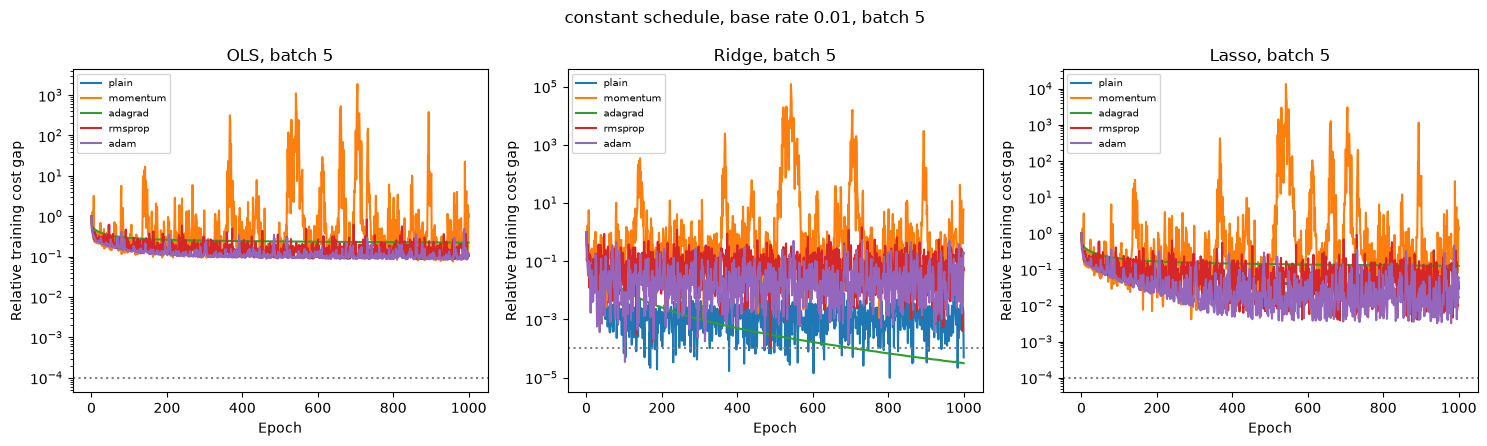

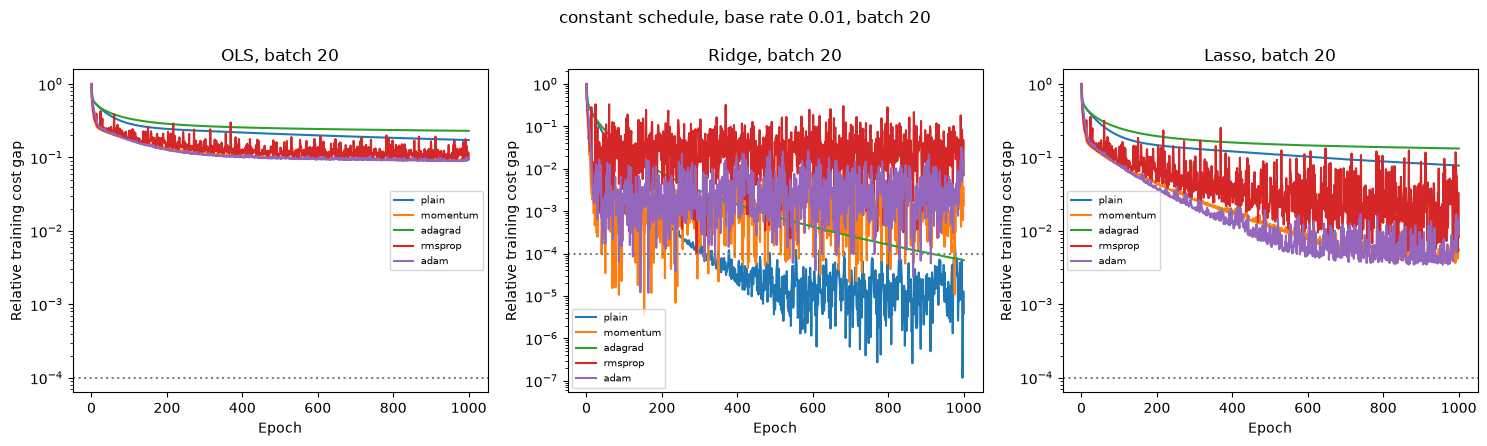

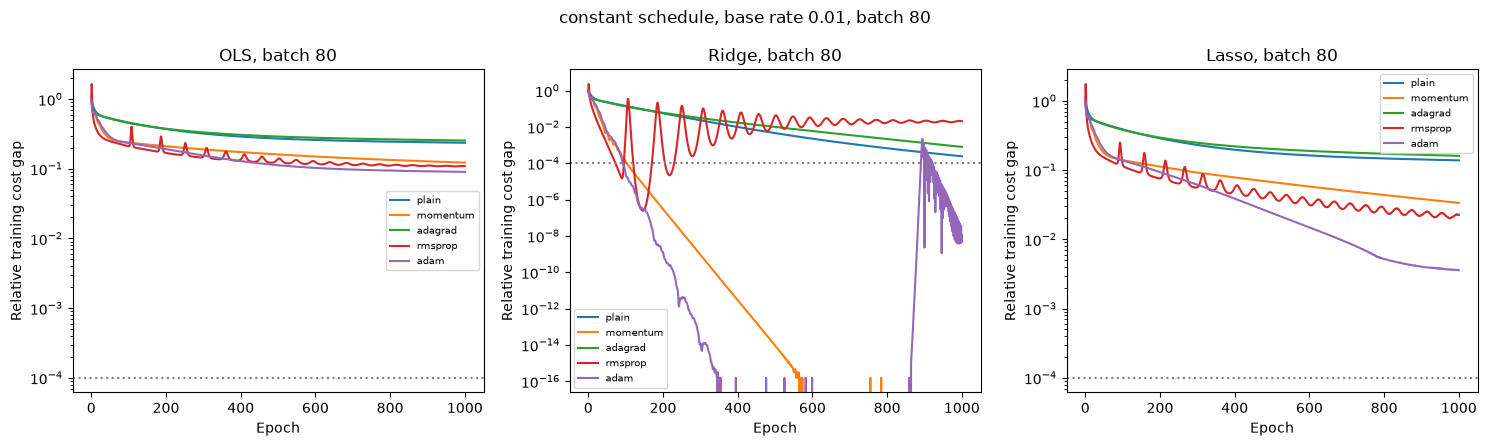

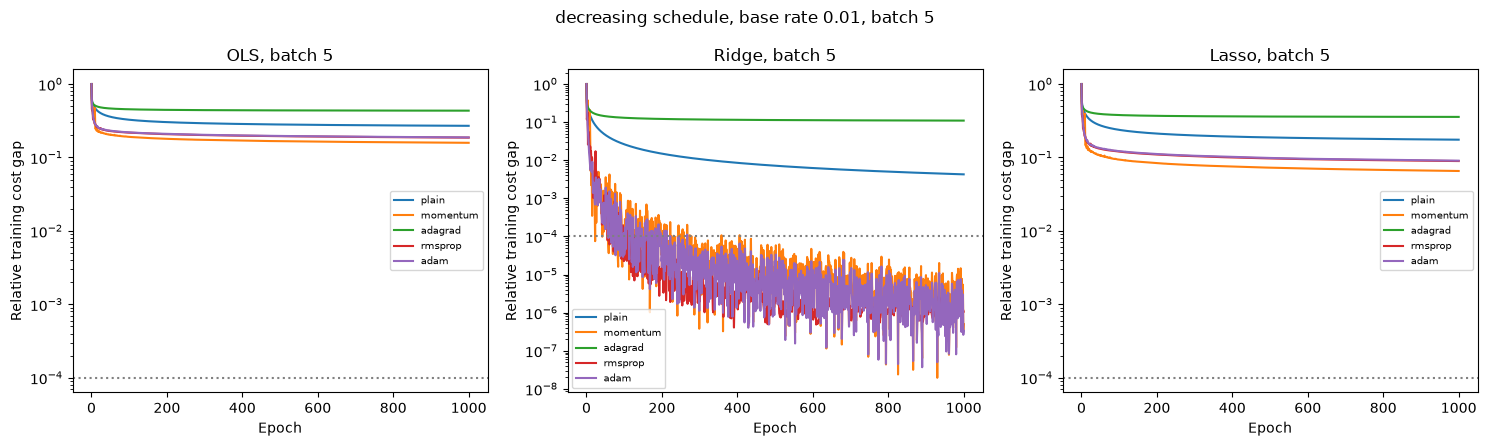

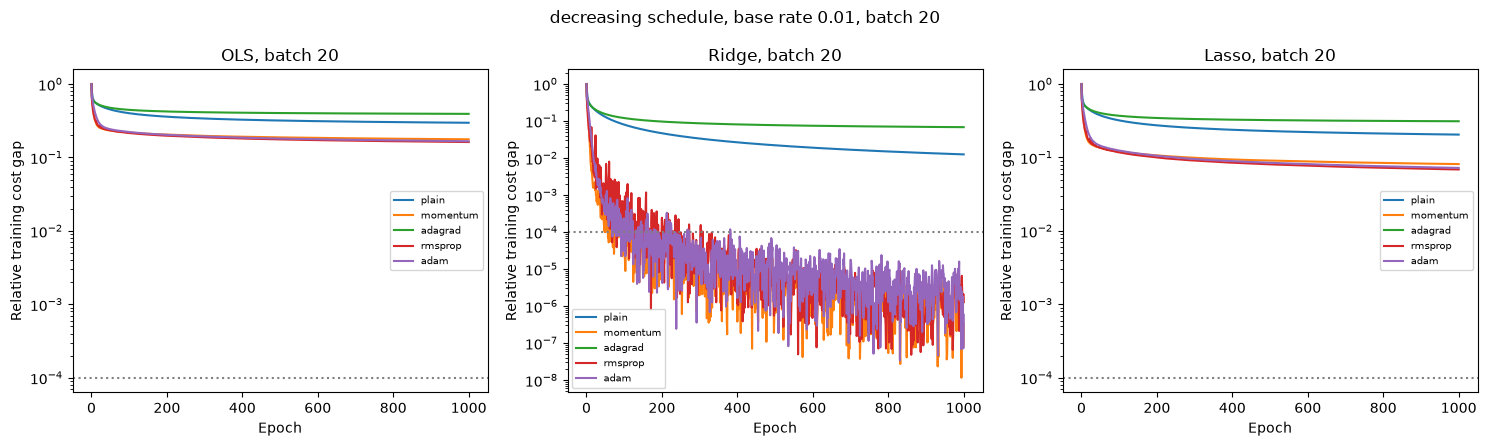

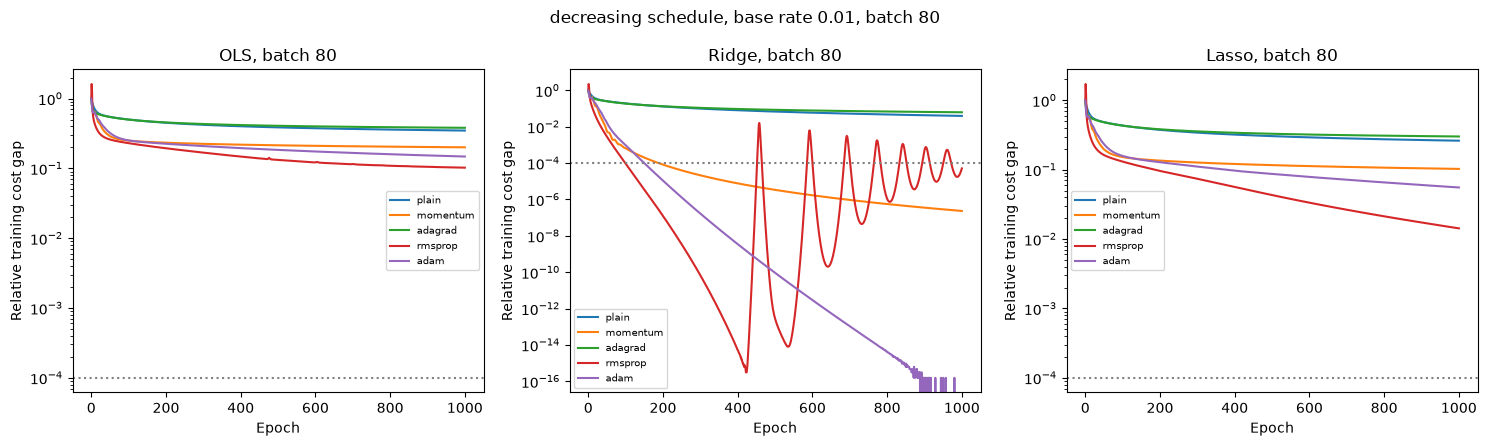

In [70]:
def plot_sgd_results(cases, runs, methods, batch_sizes, schedules, n_epochs):
    models = [case["model"] for case in cases]
    figs = []

    for schedule_name in schedules:
        for batch_size in batch_sizes:
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

            for index, model in enumerate(models):
                ax = axes[index]

                for run in runs:
                    if run["model"] == model and run["batch_size"] == batch_size and run["schedule"] == schedule_name and run["gamma"] == 0.01:
                        ax.semilogy(run["relative_history"], label=run["method"])

                ax.axhline(1e-4, color="gray", linestyle=":")
                ax.set_title(model + ", batch " + str(batch_size))
                ax.set_xlabel("Epoch")
                ax.set_ylabel("Relative training cost gap")
                ax.legend(fontsize=7)

            fig.suptitle(schedule_name + " schedule, base rate 0.01, batch " + str(batch_size))
            fig.tight_layout()
            fig.savefig("plot_sgd_" + schedule_name + "_batch_" + str(batch_size) + ".pdf", format="pdf", bbox_inches="tight")
            plt.show()
            figs.append(fig)

    return figs

sgd_figures = plot_sgd_results(sgd_cases, sgd_runs, sgd_methods, sgd_batch_sizes, sgd_schedules, sgd_epochs)

### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

In [54]:
# Your code for part i) here
from sklearn.linear_model import LassoLars
degrees = np.arange(maxdegree)
x_i = np.asarray(x).reshape(-1).copy()
y_i = np.asarray(y).reshape(-1).copy()
cv_results = {}
for folds in k:
    cv_folds = list(KFold(n_splits=folds, shuffle=True, random_state=2026).split(x_i))
    cv_results[folds] = {
        "folds": cv_folds,
        "ridge_penalties": lambdas / len(cv_folds[0][0]),
        "ols": np.zeros(maxdegree),
        "ridge": np.zeros((maxdegree, nlambdas)),
        "lasso": np.zeros((maxdegree, nlambdas))
    }
# Polynomial degrees tested in part d)
# Arrays for storing cross-validated MSE


In [55]:
for folds in k:
    cv_folds = cv_results[folds]["folds"]
    ols_cv_mse = cv_results[folds]["ols"]
    for degree in degrees:# OLS cross-validation as a function of polynomial degree
        scores = np.zeros(len(cv_folds))
        for fold, (train_inds, test_inds) in enumerate(cv_folds):
            if degree == 0:
                prediction = np.full(len(test_inds), y_i[train_inds].mean())
            else:
                prepared = prepare_polynomial(x_i[train_inds], x_i[test_inds], y_i[train_inds], degree)
                coefficients = closed_form_solution(prepared["X"], prepared["y"], 0.0)
                prediction = prepared["y_mean"] + prepared["X_test"] @ coefficients
            scores[fold] = np.mean((y_i[test_inds] - prediction)**2)
        ols_cv_mse[degree] = np.mean(scores)


In [56]:
for folds in k:
    cv_folds = cv_results[folds]["folds"]
    ridge_penalties = cv_results[folds]["ridge_penalties"]
    ridge_cv_mse = cv_results[folds]["ridge"]
    # ridge depends on two parameters  : polynomial degree and lambda



    for degree in degrees:
        for i, lmbda in enumerate(ridge_penalties):
            scores = np.zeros(len(cv_folds))
            for fold, (train_inds, test_inds) in enumerate(cv_folds):
                if degree == 0:
                    prediction = np.full(len(test_inds), y_i[train_inds].mean())
                else:
                    prepared = prepare_polynomial(x_i[train_inds], x_i[test_inds], y_i[train_inds], degree)
                    coefficients = closed_form_solution(prepared["X"], prepared["y"], lmbda)
                    prediction = prepared["y_mean"] + prepared["X_test"] @ coefficients
                scores[fold] = np.mean((y_i[test_inds] - prediction)**2)
            ridge_cv_mse[degree, i] = np.mean(scores)


In [57]:
# Origianl code with warning message :


# for degree in degrees:
   # for i, lmbda in enumerate(lambdas):
       # pipe_lasso = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Lasso(alpha=lmbda, max_iter=100000))
       # scores = cross_val_score(pipe_lasso, x_i[:, np.newaxis], y_i, cv=kfold, scoring="neg_mean_squared_error")
        #lasso_cv_mse[degree, i] = np.mean(-scores)

In [58]:
for folds in k:
    cv_folds = cv_results[folds]["folds"]
    lasso_cv_mse = cv_results[folds]["lasso"]
    for degree in degrees:
        for index, lmbda in enumerate(lambdas):
            scores = np.zeros(len(cv_folds))
            for fold, (train_inds, test_inds) in enumerate(cv_folds):
                if degree == 0:
                    prediction = np.full(len(test_inds), y_i[train_inds].mean())
                else:
                    prepared = prepare_polynomial(x_i[train_inds], x_i[test_inds], y_i[train_inds], degree)
                    model = LassoLars(alpha=lmbda / 2, fit_intercept=False, max_iter=10000)
                    model.fit(prepared["X"], prepared["y"])
                    prediction = prepared["y_mean"] + prepared["X_test"] @ model.coef_
                scores[fold] = np.mean((y_i[test_inds] - prediction)**2)
            lasso_cv_mse[degree, index] = np.mean(scores)
    print(f"Completed {folds}-fold cross-validation for OLS, Ridge and Lasso.")


Completed 5-fold cross-validation for OLS, Ridge and Lasso.
Completed 10-fold cross-validation for OLS, Ridge and Lasso.


In [64]:
cv_summary = []
for folds in k:
    result = cv_results[folds]
    best_ols = int(np.argmin(result["ols"]))
    best_ridge = np.unravel_index(np.argmin(result["ridge"]), result["ridge"].shape)
    best_lasso = np.unravel_index(np.argmin(result["lasso"]), result["lasso"].shape)
    result["best_ridge"] = best_ridge
    result["best_lasso"] = best_lasso
    rows = [
        {"Folds": folds, "Model": "OLS", "Degree": best_ols, "Mean-cost lambda": 0.0, "CV MSE": result["ols"][best_ols]},
        {"Folds": folds, "Model": "Ridge", "Degree": int(best_ridge[0]), "Mean-cost lambda": result["ridge_penalties"][best_ridge[1]], "CV MSE": result["ridge"][best_ridge]},
        {"Folds": folds, "Model": "Lasso", "Degree": int(best_lasso[0]), "Mean-cost lambda": lambdas[best_lasso[1]], "CV MSE": result["lasso"][best_lasso]}
    ]
    cv_summary.extend(rows)
    best = min(rows, key=lambda row: row["CV MSE"])
    print(f"Best model with {folds} folds: {best['Model']}, degree {best['Degree']}, mean-cost lambda {best['Mean-cost lambda']:.6g}, CV MSE {best['CV MSE']:.6g}")
print(pd.DataFrame(cv_summary).to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Best model with 5 folds: Ridge, degree 12, mean-cost lambda 1.79806e-07, CV MSE 0.0207671
Best model with 10 folds: Ridge, degree 12, mean-cost lambda 1.59828e-07, CV MSE 0.0192712
 Folds Model  Degree  Mean-cost lambda    CV MSE
     5   OLS      11                 0 0.0211129
     5 Ridge      12       1.79806e-07 0.0207671
     5 Lasso      11             1e-06 0.0211418
    10   OLS      11                 0 0.0202373
    10 Ridge      12       1.59828e-07 0.0192712
    10 Lasso      13       1.43845e-05 0.0201081


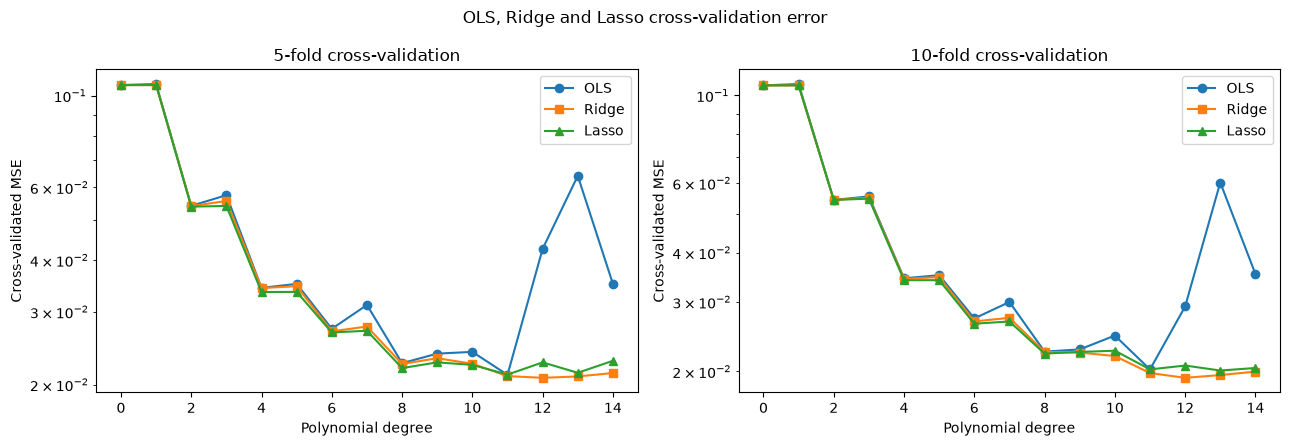

In [68]:
fig, axes = plt.subplots(1, len(k), figsize=(13, 4.5), squeeze=False)
for index, folds in enumerate(k):
    ax = axes[0, index]
    result = cv_results[folds]
    ax.semilogy(degrees, result["ols"], "o-", label="OLS")
    ax.semilogy(degrees, result["ridge"].min(axis=1), "s-", label="Ridge")
    ax.semilogy(degrees, result["lasso"].min(axis=1), "^-", label="Lasso")
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Cross-validated MSE")
    ax.set_title(f"{folds}-fold cross-validation")
    ax.legend()
fig.suptitle("OLS, Ridge and Lasso cross-validation error")
fig.tight_layout()
fig.savefig( "OLS_Ridge_Lasso_cross_validation.pdf", bbox_inches="tight")
plt.show()


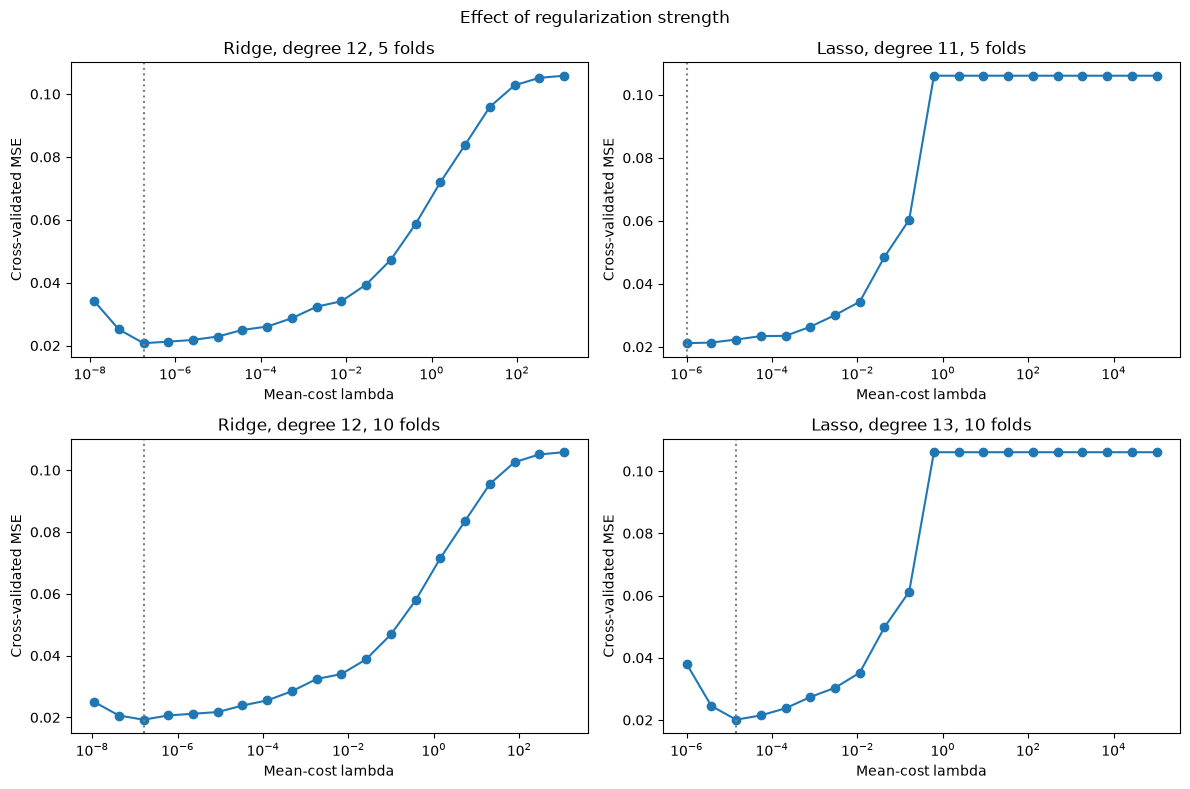

In [69]:
fig, axes = plt.subplots(len(k), 2, figsize=(12, 4 * len(k)), squeeze=False)
for row, folds in enumerate(k):
    result = cv_results[folds]
    for column, model in enumerate(("ridge", "lasso")):
        degree, penalty_index = result["best_" + model]
        penalties = result["ridge_penalties"] if model == "ridge" else lambdas
        ax = axes[row, column]
        ax.semilogx(penalties, result[model][degree], "o-")
        ax.axvline(penalties[penalty_index], color="gray", linestyle=":")
        ax.set_xlabel("Mean-cost lambda")
        ax.set_ylabel("Cross-validated MSE")
        ax.set_title(f"{model.title()}, degree {degree}, {folds} folds")
fig.suptitle("Effect of regularization strength")
fig.tight_layout()
fig.savefig("Effect_of_regularization_strength.pdf", bbox_inches="tight")
plt.show()


In [67]:
print("Increasing polynomial degree can reduce approximation bias; Ridge and Lasso shrink coefficients to control variance, potentially increasing bias.")
print("None of the methods removes the independent observation noise. CV MSE does not measure bias and variance separately.")
print("The selected models are best within the tested degrees, penalties and folds; the selection scores are not independent holdout errors.")


Increasing polynomial degree can reduce approximation bias; Ridge and Lasso shrink coefficients to control variance, potentially increasing bias.
None of the methods removes the independent observation noise. CV MSE does not measure bias and variance separately.
The selected models are best within the tested degrees, penalties and folds; the selection scores are not independent holdout errors.


## Background literature

- The lecture notes of the course, in particular Chapter 2 (Sections 2.9–2.12
  on training and test error, the bias-variance tradeoff, the bootstrap and
  cross-validation), Chapter 3 (linear regression, Ridge, Lasso, scaling) and
  Chapter 4 (gradient descent methods and automatic differentiation).
- For a discussion and derivation of the variances and mean squared errors
  using linear regression, see the
  [Lecture notes on ridge regression by Wessel N. van Wieringen](https://arxiv.org/abs/1509.09169).
- The textbook of
  [Trevor Hastie, Robert Tibshirani, Jerome H. Friedman, The Elements of Statistical Learning, Springer](https://www.springer.com/gp/book/9780387848570);
  chapters 3 and 7 are the most relevant ones for the analysis here.
- On automatic differentiation:
  [Baydin et al., Automatic differentiation in machine learning: a survey, JMLR 18 (2018)](https://jmlr.org/papers/v18/17-468.html),
  and the [JAX documentation](https://jax.readthedocs.io).

## Introduction to numerical projects

Here follows a brief recipe and recommendation on how to answer the various
questions when preparing your answers.

- Give a short description of the nature of the problem and the eventual
  numerical methods you have used.
- Describe the algorithm you have used and/or developed. Here you may find it
  convenient to use pseudocoding. In many cases you can describe the algorithm
  in the program itself.
- Include the source code of your program. Comment your program properly. You
  should have the code at your GitHub/GitLab link. You can also place the code
  in an appendix of your report.
- If possible, try to find analytic solutions, or known limits in order to test
  your program when developing the code. In this project the closed-form OLS
  and Ridge solutions are exactly such tests for your gradient descent codes.
- Include your results either in figure form or in a table. Remember to label
  your results. All tables and figures should have relevant captions and labels
  on the axes.
- Try to evaluate the reliability and numerical stability/precision of your
  results. If possible, include a qualitative and/or quantitative discussion of
  the numerical stability, eventual loss of precision etc.
- Try to give an interpretation of your results in your answers to the
  problems.
- Critique: if possible include your comments and reflections about the
  exercise, whether you felt you learnt something, ideas for improvements and
  other thoughts you've made when solving the exercise. We wish to keep this
  course at the interactive level and your comments can help us improve it.
- Try to establish a practice where you log your work at the computer lab. You
  may find such a logbook very handy at later stages in your work, especially
  when you don't properly remember what a previous test version of your program
  did. Here you could also record the time spent on solving the exercise,
  various algorithms you may have tested or other topics which you feel worthy
  of mentioning.

## Format for electronic delivery of report and programs

The preferred format for the report is a PDF file. You can also use DOC or
postscript formats or an IPython notebook file. As programming language we
prefer that you choose between C/C++, Fortran2008, Julia or Python. The
following prescription should be followed when preparing the report:

- Use Canvas to hand in your projects, log in at
  <https://www.uio.no/english/services/it/education/canvas/> with your normal
  UiO username and password.
- Upload **only** the report file or the link to your GitHub/GitLab or similar
  type of repository! For the source code file(s) you have developed please
  provide us with your link to your GitHub/GitLab or similar domain. The report
  file should include all of your discussions and a list of the codes you have
  developed. Do not include library files which are available at the course
  homepage, unless you have made specific changes to them.
- In your GitHub/GitLab or similar repository, please include a folder which
  contains selected results. These can be in the form of output from your code
  for a selected set of runs and input parameters.

Finally, we encourage you to collaborate. Optimal working groups consist of 2–3
students. You can then hand in a common report.

## Software and needed installations

If you have Python installed (we recommend Python 3) and you feel pretty
familiar with installing different packages, we recommend that you install the
following Python packages via `pip` as

    pip install numpy scipy matplotlib ipython jupyter scikit-learn pandas jax jaxlib

(`autograd` is a lighter alternative to JAX for the automatic differentiation in
parts e)–g)). For Python 3, replace `pip` with `pip3` where needed.

For OSX users we recommend also, after having installed Xcode, to install
`brew`. Brew allows for a seamless installation of additional software via for
example `brew install python3`. For Linux users, with its variety of
distributions like for example the widely popular Ubuntu distribution, you can
use `pip` as well and simply install Python as `sudo apt-get install python3`
etc.

If you don't want to install various Python packages with their dependencies
separately, we recommend [Anaconda](https://docs.anaconda.com/), an open source
distribution of the Python and R programming languages for large-scale data
processing, predictive analytics, and scientific computing, that aims to
simplify package management and deployment. Package versions are managed by the
package management system `conda`.

Popular software packages written in Python for ML are
[Scikit-learn](http://scikit-learn.org/stable/), [JAX](https://jax.readthedocs.io),
[TensorFlow](https://www.tensorflow.org/), [PyTorch](http://pytorch.org/) and
[Keras](https://keras.io/). These are all freely available at their respective
GitHub sites. They encompass communities of developers in the thousands or more,
and the number of code developers and contributors keeps increasing.